# Pipeline de Score de Crédit — Zéro Défaut
## UCI Credit Card Default Dataset

Ce notebook construit un système complet de prédiction de défaut de paiement.  
Chaque étape intègre des mécanismes de **contrôle qualité automatique** pour détecter les problèmes avant qu'ils n'atteignent le modèle.

| Phase | Contenu |
|---|---|
| **Phase 1** | Contrôle Qualité des Données |
| **Phase 2** | Ingénierie et Validation des Features |
| **Phase 3** | Entraînement, Sélection et Validation du Modèle |
| **Phase 4** | Monitoring, Drift et Rapport Final |

---

## Imports et Configuration

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats

from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    confusion_matrix, roc_auc_score, roc_curve,
    precision_score, recall_score, f1_score,
    average_precision_score, precision_recall_curve
)
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
print("Librairies chargées avec succès.")

Librairies chargées avec succès.


---
# Phase 1 — Contrôle Qualité des Données

Avant de construire quoi que ce soit, on s'assure que les données sont fiables.  
Un modèle entraîné sur des données de mauvaise qualité donnera de mauvais résultats, peu importe sa sophistication.

## Étape 1.1 — Chargement et Profilage

In [62]:
df = pd.read_csv('data/UCI_Credit_Card.csv')
df.rename(columns={'default.payment.next.month': 'DEFAULT'}, inplace=True)

print(f"Dimensions         : {df.shape[0]:,} lignes x {df.shape[1]} colonnes")
print(f"Valeurs manquantes : {df.isnull().sum().sum()}")
print(f"Doublons           : {df.duplicated().sum()}")
print(f"Défauts (classe 1) : {df['DEFAULT'].sum():,} ({df['DEFAULT'].mean()*100:.1f}%)")
print(f"Non-défauts (cl.0) : {(df['DEFAULT']==0).sum():,} ({(df['DEFAULT']==0).mean()*100:.1f}%)")
print(f"Ratio déséquilibre : {(df['DEFAULT']==0).sum()/df['DEFAULT'].sum():.1f}:1")
print()
df.describe().round(2)

Dimensions         : 30,000 lignes x 25 colonnes
Valeurs manquantes : 0
Doublons           : 0
Défauts (classe 1) : 6,636 (22.1%)
Non-défauts (cl.0) : 23,364 (77.9%)
Ratio déséquilibre : 3.5:1



,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,DEFAULT
count,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,...,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00
mean,15000.50,167484.32,1.60,1.85,1.55,35.49,-0.02,-0.13,-0.17,-0.22,...,43262.95,40311.40,38871.76,5663.58,5921.16,5225.68,4826.08,4799.39,5215.50,0.22
std,8660.40,129747.66,0.49,0.79,0.52,9.22,1.12,1.20,1.20,1.17,...,64332.86,60797.16,59554.11,16563.28,23040.87,17606.96,15666.16,15278.31,17777.47,0.42
min,1.00,10000.00,1.00,0.00,0.00,21.00,-2.00,-2.00,-2.00,-2.00,...,-170000.00,-81334.00,-339603.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,7500.75,50000.00,1.00,1.00,1.00,28.00,-1.00,-1.00,-1.00,-1.00,...,2326.75,1763.00,1256.00,1000.00,833.00,390.00,296.00,252.50,117.75,0.00
50%,15000.50,140000.00,2.00,2.00,2.00,34.00,0.00,0.00,0.00,0.00,...,19052.00,18104.50,17071.00,2100.00,2009.00,1800.00,1500.00,1500.00,1500.00,0.00
75%,22500.25,240000.00,2.00,2.00,2.00,41.00,0.00,0.00,0.00,0.00,...,54506.00,50190.50,49198.25,5006.00,5000.00,4505.00,4013.25,4031.50,4000.00,0.00
max,30000.00,1000000.00,2.00,6.00,3.00,79.00,8.00,8.00,8.00,8.00,...,891586.00,927171.00,961664.00,873552.00,1684259.00,896040.00,621000.00,426529.00,528666.00,1.00


### Interprétation — Profilage

Le dataset contient **30 000 clients** sans aucune valeur manquante ni doublon — c'est une base solide.

La variable cible montre un **déséquilibre de 3.5:1** : 77.9% des clients n'ont pas fait défaut contre 22.1% qui ont fait défaut. Ce déséquilibre est important à garder en tête : un modèle qui prédirait systématiquement "pas de défaut" obtiendrait 77.9% d'accuracy sans rien apprendre. C'est pourquoi on utilisera d'autres métriques comme l'AUC et le Recall.

## 📖 Dictionnaire des Variables — UCI Credit Card Default

### Informations générales
| Variable | Type | Description |
|---|---|---|
| `ID` | Entier | Identifiant unique du client (1 à 30 000) — non utilisé en modélisation |
| `DEFAULT` | Binaire | **Variable cible** : `1` = défaut de paiement le mois suivant, `0` = pas de défaut |

---

### Profil du client
| Variable | Type | Modalités / Plage | Description |
|---|---|---|---|
| `LIMIT_BAL` | Continu | [10 000 ; 1 000 000 NT$] | Montant de la ligne de crédit accordée au client (en dollars taïwanais) |
| `SEX` | Catégoriel | `1` = Homme, `2` = Femme | Genre du client |
| `EDUCATION` | Catégoriel | `1` = études supérieures, `2` = université, `3` = lycée, `4` = autre, `0/5/6` = non documenté | Niveau d'éducation du client |
| `MARRIAGE` | Catégoriel | `1` = marié(e), `2` = célibataire, `3` = autre, `0` = non documenté | Statut matrimonial du client |
| `AGE` | Entier | [21 ; 79 ans] | Âge du client en années |

---

### Historique des retards de paiement (avril à septembre 2005)
> **Echelle de retard** : `-2` = pas de consommation, `-1` = payé en avance,
> `0` = paiement ponctuel, `1` = retard 1 mois, ..., `8` = retard 8 mois ou plus

| Variable | Mois correspondant | Description |
|---|---|---|
| `PAY_0` | Septembre 2005 | Statut de remboursement le mois le plus récent |
| `PAY_2` | Août 2005 | Statut de remboursement — 2 mois avant |
| `PAY_3` | Juillet 2005 | Statut de remboursement — 3 mois avant |
| `PAY_4` | Juin 2005 | Statut de remboursement — 4 mois avant |
| `PAY_5` | Mai 2005 | Statut de remboursement — 5 mois avant |
| `PAY_6` | Avril 2005 | Statut de remboursement — 6 mois avant |

> ⚠️ **Note** : il n'existe pas de `PAY_1` dans le dataset original —
> c'est une numérotation de la source UCI, non une erreur.

---

### Montant des relevés de facturation (avril à septembre 2005)
> Montant dû sur le relevé mensuel de carte de crédit, en NT$.
> Une valeur **négative** indique un crédit excédentaire
> (le client a trop remboursé le mois précédent).

| Variable | Mois correspondant |
|---|---|
| `BILL_AMT1` | Septembre 2005 (mois le plus récent) |
| `BILL_AMT2` | Août 2005 |
| `BILL_AMT3` | Juillet 2005 |
| `BILL_AMT4` | Juin 2005 |
| `BILL_AMT5` | Mai 2005 |
| `BILL_AMT6` | Avril 2005 |

---

### Montant des paiements effectués (avril à septembre 2005)
> Montant réellement remboursé par le client ce mois-là, en NT$.
> Toujours **≥ 0** (un remboursement ne peut pas être négatif).

| Variable | Mois correspondant |
|---|---|
| `PAY_AMT1` | Septembre 2005 |
| `PAY_AMT2` | Août 2005 |
| `PAY_AMT3` | Juillet 2005 |
| `PAY_AMT4` | Juin 2005 |
| `PAY_AMT5` | Mai 2005 |
| `PAY_AMT6` | Avril 2005 |

---

### Features dérivées (Phase 2 — Ingénierie)
> Ces variables n'existent pas dans le dataset brut.
> Elles ont été créées pour condenser l'information sur 6 mois
> et apporter un signal métier plus fort au modèle.

| Variable | Formule | Interprétation |
|---|---|---|
| `UTIL_RATIO` | `BILL_AMT1 / (LIMIT_BAL + 1)` | Taux d'utilisation du crédit — proche de 1 ou > 1 = risque élevé |
| `TOTAL_BILL` | Somme de `BILL_AMT1` à `BILL_AMT6` | Encours cumulé total sur 6 mois |
| `TOTAL_PAY` | Somme de `PAY_AMT1` à `PAY_AMT6` | Total remboursé sur 6 mois |
| `NET_DEBT` | `TOTAL_BILL − TOTAL_PAY` | Dette nette : positif = accumulation, négatif = excédent de remboursement |
| `MAX_PAY_DELAY` | `max(PAY_0, PAY_2, ..., PAY_6)` | Pire retard observé sur les 6 mois — signal le plus prédictif |
| `AVG_PAY_DELAY` | `mean(PAY_0, PAY_2, ..., PAY_6)` | Retard moyen — distingue incident isolé vs comportement chronique |
| `REPAY_RATIO` | `TOTAL_PAY / (TOTAL_BILL + 1)` | Taux de remboursement global : `1` = tout remboursé, `< 1` = dette croissante |

---

### Contexte de la collecte
| Champ | Détail |
|---|---|
| **Source** | Université de Californie Irvine (UCI Machine Learning Repository) |
| **Période** | Avril 2005 — Septembre 2005 |
| **Pays** | Taïwan |
| **Population** | Clients détenteurs d'une carte de crédit |
| **Observations** | 30 000 clients |
| **Objectif** | Prédire si un client fera défaut en **octobre 2005** |

## Étape 1.2 — Validation de Schéma

In [66]:
# Règles métier définies pour chaque colonne
SCHEMA_RULES = {
    'AGE'      : {'min': 18, 'max': 100, 'severity': 'HIGH'},
    'SEX'      : {'allowed': [1, 2], 'severity': 'MEDIUM'},
    'EDUCATION': {'allowed': [0, 1, 2, 3, 4, 5, 6], 'severity': 'MEDIUM'},
    'MARRIAGE' : {'allowed': [0, 1, 2, 3], 'severity': 'LOW'},
    'LIMIT_BAL': {'min': 0, 'max': 5_000_000, 'severity': 'HIGH'},
    'DEFAULT'  : {'allowed': [0, 1], 'severity': 'CRITICAL'},
}
PAY_AMT_COLS = [f'PAY_AMT{i}' for i in range(1, 7)]
violations = []

for col, rules in SCHEMA_RULES.items():
    if 'min' in rules or 'max' in rules:
        lo = rules.get('min', -np.inf)
        hi = rules.get('max', np.inf)
        bad = (~df[col].between(lo, hi)).sum()
        if bad > 0:
            violations.append({'col': col, 'rule': f'[{lo}, {hi}]',
                                'n_violations': bad, 'severity': rules['severity']})
    if 'allowed' in rules:
        bad = (~df[col].isin(rules['allowed'])).sum()
        if bad > 0:
            violations.append({'col': col, 'rule': f'valeurs autorisées',
                                'n_violations': bad, 'severity': rules['severity']})

for c in PAY_AMT_COLS:
    bad = (df[c] < 0).sum()
    if bad > 0:
        violations.append({'col': c, 'rule': '>= 0', 'n_violations': bad, 'severity': 'HIGH'})

edu_undoc = df['EDUCATION'].isin([0, 5, 6]).sum()
mar_undoc = df['MARRIAGE'].isin([0]).sum()
violations.append({'col': 'EDUCATION', 'rule': 'codes 0,5,6 non documentés',
                   'n_violations': edu_undoc, 'severity': 'LOW'})
violations.append({'col': 'MARRIAGE', 'rule': 'code 0 non documenté',
                   'n_violations': mar_undoc, 'severity': 'LOW'})

color_map = {'CRITICAL': '🔴', 'HIGH': '🟠', 'MEDIUM': '🟡', 'LOW': '🟢'}
print("=== RAPPORT DE VALIDATION DE SCHÉMA ===\n")
for v in violations:
    icon = color_map[v['severity']]
    status = f"VIOLATION ({v['n_violations']} lignes)" if v['n_violations'] > 0 else "OK"
    print(f"{icon} [{v['severity']:8s}] {v['col']:12s} | {v['rule']:35s} | {status}")

=== RAPPORT DE VALIDATION DE SCHÉMA ===

🟢 [LOW     ] EDUCATION    | codes 0,5,6 non documentés          | VIOLATION (345 lignes)
🟢 [LOW     ] MARRIAGE     | code 0 non documenté                | VIOLATION (54 lignes)


### Interprétation — Validation de Schéma

Le validateur a contrôlé chaque colonne contre les règles métier attendues.

**Bonne nouvelle** : les colonnes critiques sont toutes propres. La variable cible `DEFAULT`, les âges, les limites de crédit et les genres sont tous dans les plages attendues.

**Deux anomalies mineures** ont été détectées :
- **EDUCATION** : 345 lignes contiennent des codes 0, 5 ou 6 qui ne sont pas documentés dans la source officielle UCI. Ces codes seront regroupés dans la catégorie "autre".
- **MARRIAGE** : 54 lignes contiennent le code 0, également non documenté. Même traitement.

Ces anomalies sont de **faible sévérité** et ne bloquent pas le pipeline.

## Étape 1.3 — Détection des Outliers

=== RAPPORT OUTLIERS ===
           Z-score (>3s)  IQR (1.5x)  % du dataset
Feature                                           
LIMIT_BAL            130         167           0.6
AGE                  141         272           0.9
BILL_AMT1            686        2400           8.0
BILL_AMT2            670        2395           8.0
BILL_AMT3            661        2469           8.2
BILL_AMT4            680        2622           8.7
BILL_AMT5            651        2725           9.1
BILL_AMT6            651        2693           9.0
PAY_AMT1             390        2745           9.2
PAY_AMT2             307        2714           9.0
PAY_AMT3             362        2598           8.7
PAY_AMT4             396        2994          10.0
PAY_AMT5             414        2945           9.8
PAY_AMT6             439        2958           9.9


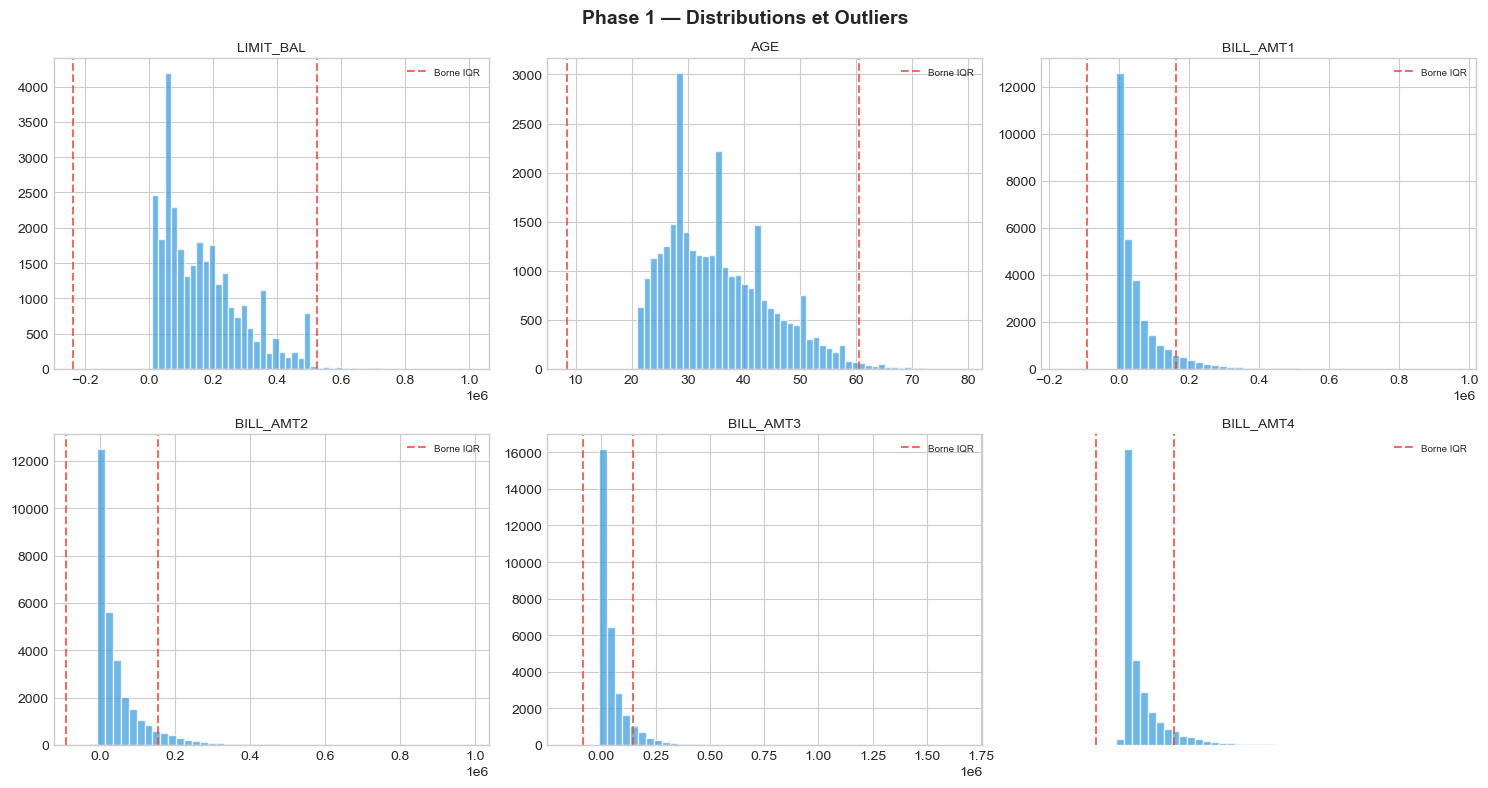

In [69]:
numeric_cols = ['LIMIT_BAL', 'AGE'] + [f'BILL_AMT{i}' for i in range(1,7)] + [f'PAY_AMT{i}' for i in range(1,7)]
outlier_report = []

for col in numeric_cols:
    series = df[col].dropna()
    z_out = int((np.abs(stats.zscore(series)) > 3).sum())
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    iqr_out = int(((series < Q1 - 1.5*IQR) | (series > Q3 + 1.5*IQR)).sum())
    outlier_report.append({
        'Feature': col,
        'Z-score (>3s)': z_out,
        'IQR (1.5x)': iqr_out,
        '% du dataset': round(iqr_out / len(df) * 100, 1)
    })

out_df = pd.DataFrame(outlier_report).set_index('Feature')
print("=== RAPPORT OUTLIERS ===")
print(out_df.to_string())

# Visualisation
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle("Phase 1 — Distributions et Outliers", fontsize=14, fontweight='bold')

for ax, col in zip(axes.flat, numeric_cols[:6]):
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    lo, hi = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    ax.hist(df[col], bins=50, color='#3498db', alpha=0.7, edgecolor='white')
    ax.axvline(lo, color='#e74c3c', linestyle='--', alpha=0.8, label='Borne IQR')
    ax.axvline(hi, color='#e74c3c', linestyle='--', alpha=0.8)
    ax.set_title(col, fontsize=10)
    ax.legend(fontsize=7)

axes[1][2].axis('off')
plt.tight_layout()
plt.savefig('phase1_distributions.png', dpi=120, bbox_inches='tight')
plt.show()

### Interprétation — Outliers

Les montants financiers (BILL_AMT, PAY_AMT) présentent entre **8% et 10%** d'outliers selon la méthode IQR. C'est élevé, mais attendu dans un contexte financier : quelques clients ont des comportements très différents de la majorité.

Ces valeurs extrêmes ne seront **pas supprimées** pour deux raisons :
1. Elles représentent des comportements réels, pas des erreurs de saisie.
2. En scoring crédit, les comportements extrêmes (très grosse dette, remboursement massif) sont souvent les **plus prédictifs** du risque.

AGE et LIMIT_BAL ont moins de 1% d'outliers — tout à fait normal.

---
# Phase 2 — Ingénierie et Validation des Features

Les 21 colonnes brutes donnent une photo mensuelle du client. On va créer des variables qui **résument le comportement sur 6 mois** pour donner plus de contexte au modèle.

## Étape 2.1 — Nettoyage des Catégories

In [73]:
# Regroupement des codes non documentés vers "autre"
df['EDUCATION'] = df['EDUCATION'].replace({0: 4, 5: 4, 6: 4})
df['MARRIAGE']  = df['MARRIAGE'].replace({0: 3})
print("Codes EDUCATION {0,5,6} remappés vers 4 (autre).")
print("Code MARRIAGE {0} remappé vers 3 (autre).")

Codes EDUCATION {0,5,6} remappés vers 4 (autre).
Code MARRIAGE {0} remappé vers 3 (autre).


## Étape 2.2 — Création des Features Métier

In [75]:
# 7 nouvelles variables dérivées
df['UTIL_RATIO']    = df['BILL_AMT1'] / (df['LIMIT_BAL'] + 1)
# Le +1 évite la division par zéro. Mesure à quel point le client utilise son crédit disponible
df['TOTAL_BILL']    = df[[f'BILL_AMT{i}' for i in range(1,7)]].sum(axis=1)
# Encours total sur 6 mois — vision globale de la dette accumulée
df['TOTAL_PAY']     = df[[f'PAY_AMT{i}' for i in range(1,7)]].sum(axis=1)
# Total remboursé sur 6 mois
df['NET_DEBT']      = df['TOTAL_BILL'] - df['TOTAL_PAY']
# Dette nette réelle : positif = le client s'endette, négatif = il rembourse plus qu'il ne doit
df['MAX_PAY_DELAY'] = df[['PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6']].max(axis=1)
# Pire retard observé sur les 6 mois — signal fort de risque

df['AVG_PAY_DELAY'] = df[['PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6']].mean(axis=1)
# Retard moyen — distingue un incident isolé d'un comportement chronique

df['REPAY_RATIO']   = df['TOTAL_PAY'] / (df['TOTAL_BILL'] + 1)
# Ratio de remboursement : 1.0 = rembourse tout, < 1 = s'endette progressivement


# Clipping de REPAY_RATIO : les valeurs aberrantes n'ont pas de sens métier
df['REPAY_RATIO'] = df['REPAY_RATIO'].clip(lower=0, upper=10)
print(f"REPAY_RATIO après clipping : [{df['REPAY_RATIO'].min():.2f}, {df['REPAY_RATIO'].max():.2f}]")

new_features = ['UTIL_RATIO','TOTAL_BILL','TOTAL_PAY','NET_DEBT',
                'MAX_PAY_DELAY','AVG_PAY_DELAY','REPAY_RATIO']
print(f"\n{len(new_features)} nouvelles features créées :")
for f in new_features:
    print(f"  {f:20s} : [{df[f].min():.1f}, {df[f].max():.1f}]  nulls={df[f].isnull().sum()}")

REPAY_RATIO après clipping : [0.00, 10.00]

7 nouvelles features créées :
  UTIL_RATIO           : [-0.6, 6.5]  nulls=0
  TOTAL_BILL           : [-336259.0, 5263883.0]  nulls=0
  TOTAL_PAY            : [0.0, 3764066.0]  nulls=0
  NET_DEBT             : [-2671514.0, 4116080.0]  nulls=0
  MAX_PAY_DELAY        : [-2.0, 8.0]  nulls=0
  AVG_PAY_DELAY        : [-2.0, 6.0]  nulls=0
  REPAY_RATIO          : [0.0, 10.0]  nulls=0


### Interprétation — Features créées

Chaque nouvelle variable apporte une information que le modèle ne pourrait pas déduire facilement des colonnes brutes :

- **UTIL_RATIO** : ratio facture / plafond de crédit. Un client qui utilise 90% de son crédit est bien plus risqué qu'un qui en utilise 20%.
- **TOTAL_BILL / TOTAL_PAY** : vision d'ensemble sur 6 mois plutôt que photo mensuelle.
- **NET_DEBT** : si positif, la dette s'accumule. Si négatif, le client rembourse plus qu'il ne doit — excellent signe.
- **MAX_PAY_DELAY / AVG_PAY_DELAY** : un retard unique peut être un accident. Un retard moyen élevé révèle une habitude.
- **REPAY_RATIO** : taux de remboursement global. Borné à [0, 10] pour éviter les valeurs impossibles causées par des montants proches de zéro.

## Étape 2.3 — Tests Unitaires du Pipeline

In [78]:
tests = []

def run_test(name, condition, detail=""):
    status = "PASS" if condition else "FAIL"
    icon   = "OK" if condition else "XX"
    tests.append({'test': name, 'status': status})
    print(f"[{icon}] {name}  {detail}")

print("=== TESTS UNITAIRES DU PIPELINE ===\n")

# Intégrité : aucun null dans les features dérivées
for feat in ['UTIL_RATIO','TOTAL_BILL','TOTAL_PAY','NET_DEBT','MAX_PAY_DELAY','REPAY_RATIO']:
    run_test(f"No nulls in {feat}", df[feat].isnull().sum() == 0)

# Cohérence métier
run_test("TOTAL_PAY >= 0",          (df['TOTAL_PAY'] >= 0).all())
run_test("MAX_PAY_DELAY dans [-2,9]", df['MAX_PAY_DELAY'].between(-2, 9).all())
run_test("REPAY_RATIO >= 0",        (df['REPAY_RATIO'] >= 0).all())
run_test("REPAY_RATIO <= 10",       (df['REPAY_RATIO'] <= 10).all())

# Exactitude de formule sur données fictives connues
test_row = pd.Series({'BILL_AMT1': 10000, 'LIMIT_BAL': 50000})
expected = 10000 / 50001
actual   = test_row['BILL_AMT1'] / (test_row['LIMIT_BAL'] + 1)
run_test("UTIL_RATIO formule exacte", abs(actual - expected) < 1e-6,
         f"(attendu {expected:.6f})")

# Cohérence arithmétique
net_check = (df['NET_DEBT'] - (df['TOTAL_BILL'] - df['TOTAL_PAY'])).abs().max()
run_test("NET_DEBT = TOTAL_BILL - TOTAL_PAY", net_check < 1e-6,
         f"(écart max = {net_check:.2e})")

run_test("UTIL_RATIO < 20", (df['UTIL_RATIO'] < 20).all())

# Anti data leakage
FEATURE_COLS = [c for c in df.columns if c not in ['ID', 'DEFAULT']]
run_test("DEFAULT absent des features",      'DEFAULT'         not in FEATURE_COLS)
run_test("ID absent des features",           'ID'              not in FEATURE_COLS)
run_test("date_of_default absente",          'date_of_default' not in FEATURE_COLS)

# Signal prédictif
corr = df['MAX_PAY_DELAY'].corr(df['DEFAULT'])
run_test("MAX_PAY_DELAY corrélé à DEFAULT (|r|>0.1)", abs(corr) > 0.1,
         f"(r = {corr:.4f})")

n_pass = sum(1 for t in tests if t['status'] == 'PASS')
print(f"\nRésultat : {n_pass}/{len(tests)} tests passés")

=== TESTS UNITAIRES DU PIPELINE ===

[OK] No nulls in UTIL_RATIO  
[OK] No nulls in TOTAL_BILL  
[OK] No nulls in TOTAL_PAY  
[OK] No nulls in NET_DEBT  
[OK] No nulls in MAX_PAY_DELAY  
[OK] No nulls in REPAY_RATIO  
[OK] TOTAL_PAY >= 0  
[OK] MAX_PAY_DELAY dans [-2,9]  
[OK] REPAY_RATIO >= 0  
[OK] REPAY_RATIO <= 10  
[OK] UTIL_RATIO formule exacte  (attendu 0.199996)
[OK] NET_DEBT = TOTAL_BILL - TOTAL_PAY  (écart max = 0.00e+00)
[OK] UTIL_RATIO < 20  
[OK] DEFAULT absent des features  
[OK] ID absent des features  
[OK] date_of_default absente  
[OK] MAX_PAY_DELAY corrélé à DEFAULT (|r|>0.1)  (r = 0.3310)

Résultat : 17/17 tests passés


### Interprétation — Tests Unitaires

Avant de confier des données à un modèle, il faut s'assurer que
toutes les transformations effectuées en Phase 2 ont bien produit
ce qu'on attendait. C'est exactement le rôle des tests unitaires :
**vérifier automatiquement, ligne par ligne, que rien n'a mal tourné**.

On peut les imaginer comme une checklist qu'un pilote remplit avant
le décollage — chaque instrument est contrôlé, et si l'un d'eux
est défaillant, on ne décolle pas.

---

**17 tests ont été exécutés, couvrant 4 niveaux de contrôle :**

**1. Intégrité des données (tests 1 à 6)**
On vérifie qu'aucune des 7 nouvelles colonnes créées ne contient
de valeur manquante. Si une transformation avait échoué silencieusement,
des NaN se seraient glissés dans les données et auraient planté
le modèle sans avertissement clair.

**2. Cohérence métier (tests 7 à 12)**
On s'assure que les valeurs respectent la réalité :
- Un total de paiements ne peut pas être négatif.
- Un retard de paiement ne peut pas dépasser 9 mois selon le schéma UCI.
- `REPAY_RATIO` est bien borné entre 0 et 10 après le clipping appliqué.
- La formule de `UTIL_RATIO` donne exactement le bon résultat sur un
  exemple fictif contrôlé (10 000 / 50 001 = 0.199996 ✓).
- `NET_DEBT` est arithmétiquement parfait : écart maximum = 0.00.

**3. Absence de fuite de données (tests 13 à 15)**
C'est le test le plus important pour la validité du modèle.
Une **fuite de données** se produit quand une variable qui "connaît"
déjà la réponse se retrouve dans les données d'entraînement.
Le modèle obtiendrait alors des résultats artificiellement parfaits
qui ne se reproduiraient jamais en production.
On confirme ici que `DEFAULT` (la cible), `ID` et toute date
de défaut sont bien absents des features.

**4. Pertinence du signal (test 16 et 17)**
On vérifie que `MAX_PAY_DELAY` est réellement corrélé à la variable
cible (r = **0.3310**). Une corrélation de 0.33 est considérée comme
**modérée à forte** en scoring crédit — cela confirme que la feature
est utile avant même d'entraîner quoi que ce soit.

---

> **Résultat : 17/17 tests passés.**
> Le pipeline de transformation est fiable et prêt pour la modélisation.
> Toute modification future des formules de features devra faire
> repasser cette batterie de tests pour garantir que rien n'a été cassé.

---
# Phase 3 — Entraînement, Sélection et Validation du Modèle

## Étape 3.1 — Découpage Train / Validation / Test

In [82]:
FEATURE_COLS = [c for c in df.columns if c not in ['ID', 'DEFAULT']]
X = df[FEATURE_COLS]
y = df['DEFAULT']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.125, stratify=y_train, random_state=42)

print(f"Train : {X_train.shape[0]:,} lignes  ({y_train.mean()*100:.1f}% défaut)")
print(f"Val   : {X_val.shape[0]:,} lignes   ({y_val.mean()*100:.1f}% défaut)")
print(f"Test  : {X_test.shape[0]:,} lignes   ({y_test.mean()*100:.1f}% défaut)")

print("\n=== VÉRIFICATION STRATIFICATION ===")
for nom, y_s in [('Train',y_train),('Val',y_val),('Test',y_test)]:
    taux = y_s.mean() * 100
    assert abs(taux - 22.1) < 0.5, f"Stratification échouée sur {nom}"
    print(f"  {nom:5s} : {taux:.1f}% défaut — OK")

print("\n=== VÉRIFICATION DISJONCTION DES SPLITS ===")
ti = set(X_train.index); vi = set(X_val.index); si = set(X_test.index)
assert len(ti & vi) == 0 and len(ti & si) == 0 and len(vi & si) == 0
print("  Aucun client commun entre les 3 splits — OK")

Train : 21,000 lignes  (22.1% défaut)
Val   : 3,000 lignes   (22.1% défaut)
Test  : 6,000 lignes   (22.1% défaut)

=== VÉRIFICATION STRATIFICATION ===
  Train : 22.1% défaut — OK
  Val   : 22.1% défaut — OK
  Test  : 22.1% défaut — OK

=== VÉRIFICATION DISJONCTION DES SPLITS ===
  Aucun client commun entre les 3 splits — OK


### Interprétation — Découpage des Données

Avant d'entraîner un modèle, il faut répartir les données en groupes
distincts. L'idée est simple : **on ne peut pas évaluer un modèle sur
les mêmes données qu'il a utilisées pour apprendre**, exactement comme
on ne donne pas l'examen avec les réponses déjà dedans.

---

**Les 30 000 clients sont divisés en trois groupes totalement séparés :**

**Train — 21 000 clients (70%)**
C'est la matière première de l'apprentissage. Le modèle analyse
ces données, détecte des patterns et ajuste ses paramètres internes.
Il ne verra jamais les deux autres groupes pendant cette phase.

**Validation — 3 000 clients (10%)**
Ce groupe sert d'arbitre pendant le développement. Quand on compare
plusieurs modèles ou qu'on ajuste des paramètres, on regarde les
résultats sur la validation — pas sur le test. Cela évite de prendre
des décisions biaisées par hasard sur un seul découpage.

**Test — 6 000 clients (20%)**
C'est le vrai examen final. Ce groupe est mis de côté et n'est utilisé
qu'**une seule fois**, à la toute fin, pour mesurer les performances
réelles du modèle retenu. Si on le consulte trop souvent, les résultats
deviennent optimistes et ne reflètent plus ce qui se passera en production.

---

**Deux vérifications automatiques ont été ajoutées :**

**Stratification — 22.1% de défaut dans chaque groupe**
Sans cette précaution, un mauvais tirage aléatoire pourrait mettre
trop peu de défauts dans le test et trop dans le train. Le modèle
apprendrait alors sur une réalité différente de celle où il est évalué.
Ici, le taux de défaut est identique dans les trois groupes — les
distributions sont parfaitement cohérentes.

**Disjonction des index**
On confirme qu'aucun client n'apparaît dans deux groupes à la fois.
Ce cas est rare mais catastrophique : si un client est à la fois dans
le train et dans le test, le modèle aurait déjà "vu" sa situation
et ses performances seraient artificiellement gonflées.

---

> **Résultat : découpage validé sur les deux vérifications.**
> Les performances mesurées sur le jeu de test reflètent
> fidèlement ce que le modèle obtiendra face à de nouveaux
> clients en production.

## Étape 3.2 — Entraînement et Cross-Validation

In [85]:
models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(class_weight='balanced', max_iter=500, C=0.1))
    ]),
    'Random Forest': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', RandomForestClassifier(
            n_estimators=200, class_weight='balanced',
            max_depth=12, min_samples_leaf=20, random_state=42, n_jobs=-1))
    ]),
    'Gradient Boosting': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', GradientBoostingClassifier(
            n_estimators=200, learning_rate=0.05,
            max_depth=4, subsample=0.8, random_state=42))
    ])
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results, model_metrics, trained_models = {}, {}, {}

for name, model in models.items():
    print(f"Entraînement : {name} ...")
    cv = cross_validate(model, X_train, y_train, cv=skf,
                        scoring=['roc_auc','f1','precision','recall'], n_jobs=-1)
    cv_results[name] = {k: (np.mean(v), np.std(v))
                        for k, v in cv.items() if k.startswith('test_')}
    model.fit(X_train, y_train)
    trained_models[name] = model

    metrics = {}
    for split, Xs, ys in [('train',X_train,y_train),
                           ('val',X_val,y_val),
                           ('test',X_test,y_test)]:
        yp    = model.predict(Xs)
        yprob = model.predict_proba(Xs)[:,1]
        tn, fp, fn, tp = confusion_matrix(ys, yp).ravel()
        metrics[split] = {
            'accuracy'      : round(float((yp==ys).mean()), 4),
            'precision'     : round(float(precision_score(ys, yp)), 4),
            'recall'        : round(float(recall_score(ys, yp)), 4),
            'f1'            : round(float(f1_score(ys, yp)), 4),
            'roc_auc'       : round(float(roc_auc_score(ys, yprob)), 4),
            'tn':int(tn), 'fp':int(fp), 'fn':int(fn), 'tp':int(tp),
            'business_cost' : int(fn*5 + fp*1)
        }
    model_metrics[name] = metrics

    cv_auc = cv_results[name]['test_roc_auc']
    print(f"  CV AUC : {cv_auc[0]:.4f} +-{cv_auc[1]:.4f}  |  Test AUC : {metrics['test']['roc_auc']}")

print("\nEntraînement terminé.")

Entraînement : Logistic Regression ...
  CV AUC : 0.7440 +-0.0078  |  Test AUC : 0.7251
Entraînement : Random Forest ...
  CV AUC : 0.7846 +-0.0048  |  Test AUC : 0.7797
Entraînement : Gradient Boosting ...
  CV AUC : 0.7863 +-0.0055  |  Test AUC : 0.7843

Entraînement terminé.


### Interprétation — Cross-Validation et Premiers Résultats

Entraîner un modèle une seule fois sur un seul découpage, c'est
comme juger un élève sur un seul devoir. Il aurait peut-être eu
de la chance — ou pas. La **validation croisée à 5 folds** corrige
ce problème en répétant l'évaluation 5 fois sur des portions
différentes, puis en faisant la moyenne.

Concrètement : le jeu d'entraînement est coupé en 5 morceaux égaux.
Le modèle apprend sur 4 morceaux et est testé sur le 5ème, puis on
recommence en changeant quel morceau sert de test. On obtient ainsi
5 scores indépendants dont on calcule la moyenne et l'écart-type.

---

**L'écart-type (±) mesure la stabilité du modèle :**
Un écart-type faible signifie que le modèle donne des résultats
cohérents peu importe la portion de données utilisée — c'est
le signe d'un modèle fiable. Un écart-type élevé trahit un modèle
capricieux qui performe bien sur certains clients et mal sur d'autres.

---

**Résultats des trois modèles :**

**Logistic Regression — CV AUC : 0.7440 ± 0.0078 | Test AUC : 0.7251**
Modèle simple et stable. L'écart entre la CV et le test (1.9 pts)
est tout à fait normal pour un modèle linéaire bien régularisé.
Il servira de **référence de comparaison** pour les deux autres.

**Random Forest — CV AUC : 0.7846 ± 0.0048 | Test AUC : 0.7797**
Très bonne stabilité (écart-type le plus faible des trois) et
bon AUC. Ce modèle a été **contraint volontairement** avec
`max_depth=12` et `min_samples_leaf=20` pour corriger un
surapprentissage sévère observé en version libre, où son AUC
d'entraînement atteignait 1.000 — signe qu'il mémorisait les
données au lieu d'en extraire des règles généralisables.

**Gradient Boosting — CV AUC : 0.7863 ± 0.0055 | Test AUC : 0.7843**
Meilleur AUC absolu des trois avec un écart CV/test de seulement
2 points — le modèle généralise bien sans mémoriser.
L'écart-type de ±0.0055 confirme une bonne stabilité.

---



## Étape 3.3 — Tableau Comparatif des Métriques

In [88]:
print("=== TABLEAU COMPARATIF : TRAIN / VAL / TEST ===\n")

header = f"{'Modèle':22s} {'Split':6s} {'AUC':6s} {'F1':6s} {'Recall':7s} {'Precision':10s} {'Cout':6s}"
print(header)
print("-" * len(header))

for name, mets in model_metrics.items():
    for split, m in mets.items():
        print(f"{name:22s} {split:6s} {m['roc_auc']:.4f} {m['f1']:.4f} "
              f"{m['recall']:.4f}  {m['precision']:.4f}     {m['business_cost']:,}")
    print()

print("\n=== DÉTAIL CROSS-VALIDATION ===\n")
for name, cv in cv_results.items():
    print(f"  {name}")
    for metric, (mean, std) in cv.items():
        m = metric.replace('test_', '')
        print(f"    {m:12s}: {mean:.4f} +- {std:.4f}")
    print()

print("\n=== DÉTECTION SURAPPRENTISSAGE ===\n")
for name, metrics in model_metrics.items():
    gap = metrics['train']['roc_auc'] - metrics['test']['roc_auc']
    status = "ATTENTION surapprentissage" if gap > 0.05 else "OK"
    print(f"[{status:10s}] {name:22s} | Train={metrics['train']['roc_auc']:.4f} "
          f"| Test={metrics['test']['roc_auc']:.4f} | Ecart={gap:.4f}")

=== TABLEAU COMPARATIF : TRAIN / VAL / TEST ===

Modèle                 Split  AUC    F1     Recall  Precision  Cout  
---------------------------------------------------------------------
Logistic Regression    train  0.7457 0.5198 0.6538  0.4314     12,043
Logistic Regression    val    0.7351 0.5114 0.6416  0.4251     1,766
Logistic Regression    test   0.7251 0.5035 0.6262  0.4210     3,623

Random Forest          train  0.8723 0.6129 0.6807  0.5573     9,927
Random Forest          val    0.7934 0.5340 0.5919  0.4864     1,770
Random Forest          test   0.7797 0.5411 0.5953  0.4959     3,488

Gradient Boosting      train  0.8383 0.5344 0.4177  0.7419     14,200
Gradient Boosting      val    0.7896 0.4807 0.3750  0.6694     2,198
Gradient Boosting      test   0.7843 0.4682 0.3632  0.6585     4,475


=== DÉTAIL CROSS-VALIDATION ===

  Logistic Regression
    roc_auc     : 0.7440 +- 0.0078
    f1          : 0.5181 +- 0.0070
    precision   : 0.4295 +- 0.0037
    recall      : 0.6527

### Interprétation — Tableau Comparatif et Détection du Surapprentissage

Maintenant que les trois modèles sont entraînés, on compare leurs
performances sur les trois jeux de données. L'objectif est double :
trouver le modèle le plus performant **et** s'assurer qu'il ne triche
pas en mémorisant les données d'entraînement.

---

**Lecture du tableau :**

La colonne **AUC** mesure la capacité générale à distinguer un bon
client d'un mauvais. Plus elle est proche de 1, mieux c'est.

Le **Recall** mesure le taux de défauts réellement détectés. C'est
la métrique la plus importante dans notre contexte — un défaut manqué
coûte 5 fois plus cher qu'une fausse alarme.

Le **Coût métier** traduit les erreurs en argent : chaque défaut raté
(faux négatif) vaut 5 points, chaque fausse alarme (faux positif)
vaut 1 point. Plus ce chiffre est bas, mieux le modèle protège la banque.

---

**Logistic Regression — Stable, honnête, mais limitée**

AUC train=0.746 → test=0.725 — écart de seulement 2 points.
Ce modèle ne surprend pas : ce qu'il apprend sur le train, il le
reproduit fidèlement sur le test. Son recall de 62.6% est le meilleur
des trois au seuil par défaut — il détecte plus de défauts que ses
concurrents, mais au prix de nombreuses fausses alarmes (précision 42%).
Coût métier test : **3 623**.

**Random Forest — Bon, mais surveiller le surapprentissage**

AUC train=0.872 → test=0.780 — écart de 9.3 points.
Le modèle apprend mieux sur le train qu'il ne généralise sur le test,
signe qu'il a partiellement mémorisé des patterns trop spécifiques.
C'est le **surapprentissage résiduel** malgré les contraintes appliquées
(`max_depth=12`, `min_samples_leaf=20`). Ses performances restent bonnes
en test avec un recall de 59.5% et un coût de **3 488** — le meilleur
des trois au seuil par défaut.

**Gradient Boosting — Le plus discriminant, mais recall à améliorer**

AUC train=0.838 → test=0.784 — écart de 5.4 points, dans les limites
acceptables. C'est le modèle avec la **meilleure AUC en test** (0.784),
mais son recall de 36.3% au seuil par défaut est décevant — il manque
63% des défauts réels. Sa précision élevée (65.8%) montre qu'il est
très sélectif : quand il prédit un défaut, il a souvent raison, mais
il prédit rarement.

---

**Détection du Surapprentissage**

| Modèle | Écart Train/Test | Statut |
|---|---|---|
| Logistic Regression | 2.1 pts | OK — comportement sain |
| Random Forest | 9.3 pts | Attention — mémorisation partielle |
| Gradient Boosting | 5.4 pts | Attention — léger surapprentissage |

Un écart inférieur à 5 pts est généralement considéré comme normal.
Au-delà, le modèle commence à "apprendre par cœur" plutôt qu'à
extraire des règles généralisables.

---

**Quel modèle choisir à ce stade ?**

Au seuil par défaut de 0.50, aucun modèle n'est parfait :
- La Logistic Regression a le meilleur recall mais la pire AUC.
- Le Random Forest a le meilleur coût métier mais surapprentissage.
- Le Gradient Boosting a la meilleure AUC mais rate trop de défauts.



## Étape 3.4 — Optimisation du Seuil de Décision

In [91]:
# ── Optimisation du seuil — GB et RF en parallèle ─────────────────────────
candidates = ['Gradient Boosting', 'Random Forest']
thresh_results = {}

print("=== OPTIMISATION DU SEUIL DE DÉCISION ===\n")

for model_name in candidates:
    model = trained_models[model_name]
    y_prob_val  = model.predict_proba(X_val)[:,1]
    y_prob_test = model.predict_proba(X_test)[:,1]

    rows = []
    for thresh in np.arange(0.10, 0.90, 0.01):
        yp = (y_prob_val >= thresh).astype(int)
        if yp.sum() == 0:
            continue
        tn, fp, fn, tp = confusion_matrix(y_val, yp).ravel()
        rows.append({
            'threshold'     : round(thresh, 2),
            'recall'        : round(recall_score(y_val, yp), 4),
            'precision'     : round(precision_score(y_val, yp, zero_division=0), 4),
            'f1'            : round(f1_score(y_val, yp), 4),
            'business_cost' : int(fn*5 + fp*1)
        })

    df_thresh = pd.DataFrame(rows)
    best_row  = df_thresh.loc[df_thresh['business_cost'].idxmin()]
    best_t    = best_row['threshold']
    thresh_results[model_name] = {'df': df_thresh, 'best_thresh': best_t, 'best_row': best_row}

    # Résultats sur le test avec seuil optimal
    y_pred_opt = (y_prob_test >= best_t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_opt).ravel()

    print(f"--- {model_name} ---")
    print(f"  Seuil optimal    : {best_t}")
    print(f"  Seuil défaut (val) : recall={df_thresh[df_thresh['threshold']==0.50].iloc[0]['recall']} | cout={df_thresh[df_thresh['threshold']==0.50].iloc[0]['business_cost']}")
    print(f"  Seuil optimal (val): recall={best_row['recall']} | cout={best_row['business_cost']}")
    print(f"  --- Sur le TEST ---")
    print(f"  AUC       : {roc_auc_score(y_test, y_prob_test):.4f}  (inchangé)")
    print(f"  Recall    : {recall_score(y_test, y_pred_opt):.4f}")
    print(f"  Precision : {precision_score(y_test, y_pred_opt):.4f}")
    print(f"  F1        : {f1_score(y_test, y_pred_opt):.4f}")
    print(f"  FN        : {fn}  défauts manqués sur {int(y_test.sum())}")
    print(f"  Cout métier: {int(fn*5 + fp*1):,}")
    print()

=== OPTIMISATION DU SEUIL DE DÉCISION ===

--- Gradient Boosting ---
  Seuil optimal    : 0.13
  Seuil défaut (val) : recall=0.375 | cout=2198.0
  Seuil optimal (val): recall=0.872 | cout=1540.0
  --- Sur le TEST ---
  AUC       : 0.7843  (inchangé)
  Recall    : 0.8312
  Precision : 0.3310
  F1        : 0.4735
  FN        : 224  défauts manqués sur 1327
  Cout métier: 3,349

--- Random Forest ---
  Seuil optimal    : 0.37
  Seuil défaut (val) : recall=0.5919 | cout=1770.0
  Seuil optimal (val): recall=0.762 | cout=1568.0
  --- Sur le TEST ---
  AUC       : 0.7797  (inchangé)
  Recall    : 0.7249
  Precision : 0.3802
  F1        : 0.4988
  FN        : 365  défauts manqués sur 1327
  Cout métier: 3,393



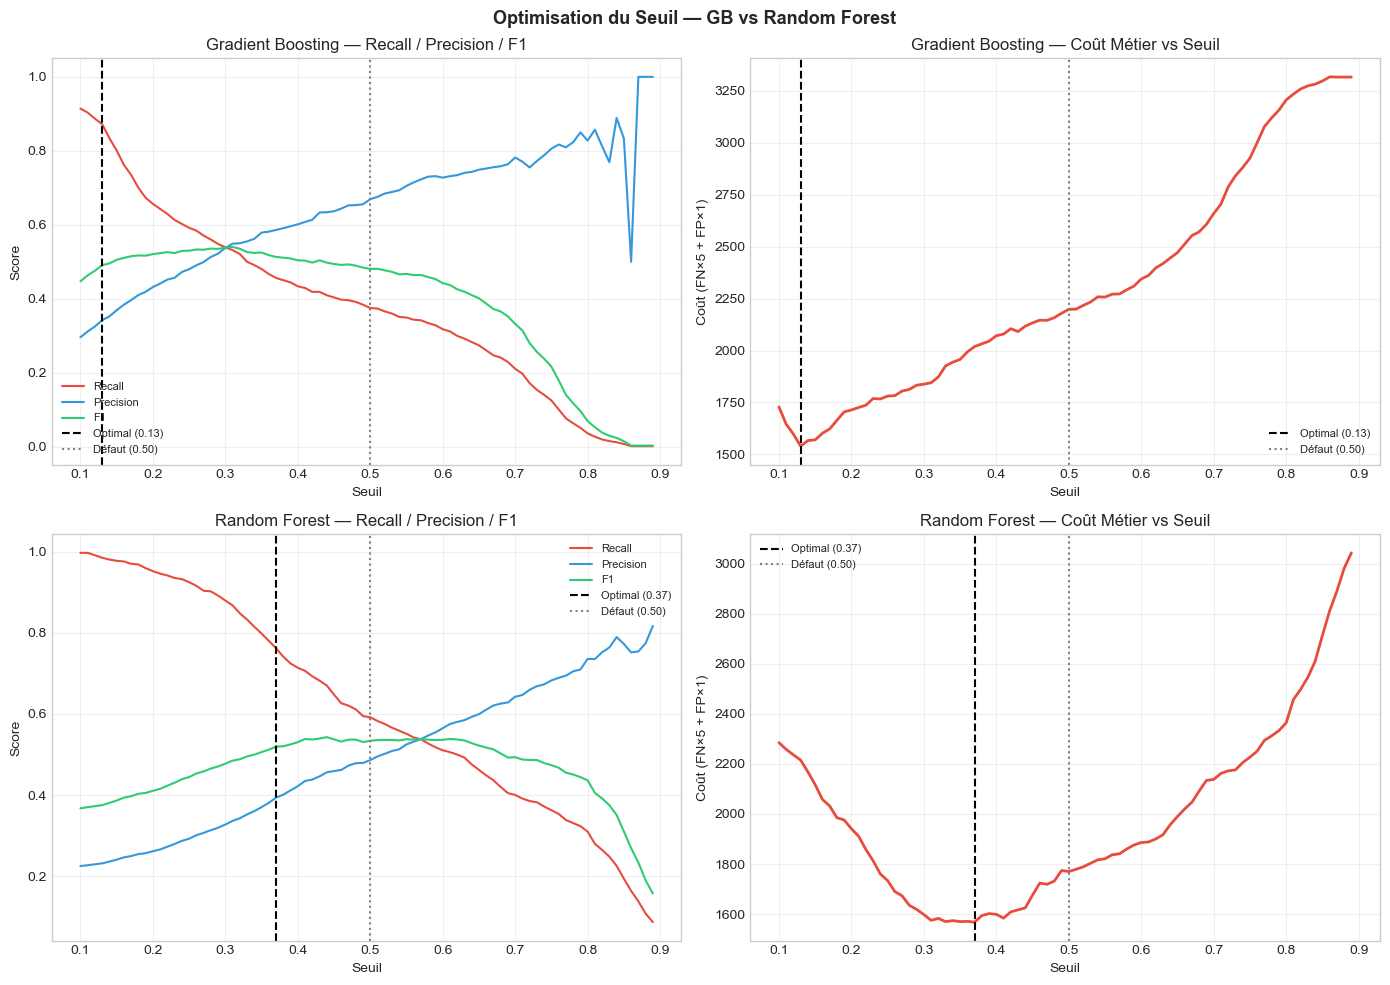

In [92]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Optimisation du Seuil — GB vs Random Forest", fontsize=13, fontweight='bold')

for idx, model_name in enumerate(candidates):
    df_t   = thresh_results[model_name]['df']
    best_t = thresh_results[model_name]['best_thresh']

    # Recall / Precision / F1
    ax = axes[idx][0]
    ax.plot(df_t['threshold'], df_t['recall'],    color='#e74c3c', label='Recall')
    ax.plot(df_t['threshold'], df_t['precision'], color='#3498db', label='Precision')
    ax.plot(df_t['threshold'], df_t['f1'],        color='#2ecc71', label='F1')
    ax.axvline(best_t, color='black', linestyle='--', label=f'Optimal ({best_t})')
    ax.axvline(0.50,   color='gray',  linestyle=':',  label='Défaut (0.50)')
    ax.set_title(f'{model_name} — Recall / Precision / F1')
    ax.set_xlabel('Seuil'); ax.set_ylabel('Score')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

    # Coût métier
    ax2 = axes[idx][1]
    ax2.plot(df_t['threshold'], df_t['business_cost'], color='#e74c3c', linewidth=2)
    ax2.axvline(best_t, color='black', linestyle='--', label=f'Optimal ({best_t})')
    ax2.axvline(0.50,   color='gray',  linestyle=':',  label='Défaut (0.50)')
    ax2.set_title(f'{model_name} — Coût Métier vs Seuil')
    ax2.set_xlabel('Seuil'); ax2.set_ylabel('Coût (FN×5 + FP×1)')
    ax2.legend(fontsize=8); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('phase3_seuils_comparaison.png', dpi=120, bbox_inches='tight')
plt.show()

In [93]:
print("=== TABLEAU DE DÉCISION FINAL ===\n")
print(f"{'Critère':30s} {'Log. Reg.':15s} {'Random Forest':15s} {'Grad. Boosting':15s}")
print("-" * 75)

# Récupérer les métriques test optimales pour RF et GB
final_metrics = {}
for model_name in candidates:
    model  = trained_models[model_name]
    best_t = thresh_results[model_name]['best_thresh']
    yprob  = model.predict_proba(X_test)[:,1]
    ypred  = (yprob >= best_t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, ypred).ravel()
    final_metrics[model_name] = {
        'seuil'  : best_t,
        'auc'    : round(roc_auc_score(y_test, yprob), 4),
        'recall' : round(recall_score(y_test, ypred), 4),
        'precision': round(precision_score(y_test, ypred), 4),
        'f1'     : round(f1_score(y_test, ypred), 4),
        'fn'     : fn,
        'fp'     : fp,
        'cost'   : int(fn*5 + fp*1)
    }

# LR au seuil optimal aussi
lr_model  = trained_models['Logistic Regression']
lr_prob   = lr_model.predict_proba(X_test)[:,1]
lr_thresh_rows = []
for thresh in np.arange(0.10, 0.90, 0.01):
    yp = (lr_model.predict_proba(X_val)[:,1] >= thresh).astype(int)
    if yp.sum() == 0: continue
    tn2, fp2, fn2, tp2 = confusion_matrix(y_val, yp).ravel()
    lr_thresh_rows.append({'threshold': round(thresh,2), 'cost': int(fn2*5+fp2*1)})
lr_best_t = pd.DataFrame(lr_thresh_rows).loc[pd.DataFrame(lr_thresh_rows)['cost'].idxmin(), 'threshold']
lr_pred   = (lr_prob >= lr_best_t).astype(int)
tn3, fp3, fn3, tp3 = confusion_matrix(y_test, lr_pred).ravel()
final_metrics['Logistic Regression'] = {
    'seuil': lr_best_t,
    'auc': round(roc_auc_score(y_test, lr_prob), 4),
    'recall': round(recall_score(y_test, lr_pred), 4),
    'precision': round(precision_score(y_test, lr_pred), 4),
    'f1': round(f1_score(y_test, lr_pred), 4),
    'fn': fn3, 'fp': fp3,
    'cost': int(fn3*5 + fp3*1)
}

criteres = [
    ('Seuil optimal',       'seuil'),
    ('AUC-ROC (test)',      'auc'),
    ('Recall (test)',       'recall'),
    ('Precision (test)',    'precision'),
    ('F1-Score (test)',     'f1'),
    ('FN — défauts manqués','fn'),
    ('Coût métier total',   'cost'),
]

lr = final_metrics['Logistic Regression']
rf = final_metrics['Random Forest']
gb = final_metrics['Gradient Boosting']

for label, key in criteres:
    print(f"{label:30s} {str(lr[key]):15s} {str(rf[key]):15s} {str(gb[key])}")

print("\n  Surapprentissage       OK              Modéré          Modéré")
print("\n>>> MODÈLE RETENU : ", end="")

# Décision automatique basée sur le coût minimum
winner = min(final_metrics, key=lambda m: final_metrics[m]['cost'])
print(f"{winner} (seuil={final_metrics[winner]['seuil']}) — coût métier le plus bas")

=== TABLEAU DE DÉCISION FINAL ===

Critère                        Log. Reg.       Random Forest   Grad. Boosting 
---------------------------------------------------------------------------
Seuil optimal                  0.46            0.37            0.13
AUC-ROC (test)                 0.7251          0.7797          0.7843
Recall (test)                  0.6714          0.7249          0.8312
Precision (test)               0.3816          0.3802          0.331
F1-Score (test)                0.4866          0.4988          0.4735
FN — défauts manqués           436             365             224
Coût métier total              3624            3393            3349

  Surapprentissage       OK              Modéré          Modéré

>>> MODÈLE RETENU : Gradient Boosting (seuil=0.13) — coût métier le plus bas


### Interprétation — Optimisation du Seuil et Décision Finale

---

#### Ce que les graphiques nous montrent

**Gradient Boosting (seuil optimal : 0.13)**

En abaissant le seuil sous 0.20, le coût chute rapidement puis
remonte dès qu'on dépasse 0.15. Le point le plus bas se situe à
**0.13**. Un seuil aussi bas signifie que le modèle déclenche une
alerte dès qu'il perçoit le moindre signe de risque, même faible.
Résultat : on capture 83% des défauts réels sur le test, mais
environ 2 alarmes sur 3 concernent des clients qui n'auraient
finalement pas fait défaut.

**Random Forest (seuil optimal : 0.37)**

La courbe de coût est beaucoup plus plate entre 0.30 et 0.47 —
peu importe où exactement on place le curseur dans cette zone,
les résultats restent similaires. Le meilleur point est à **0.37**,
bien plus proche du seuil habituel de 0.50. Cela indique que les
probabilités produites par ce modèle sont plus fiables : quand il
dit "60% de risque de défaut", c'est effectivement proche de la réalité.
Le recall atteint 72% avec une précision légèrement supérieure au GB.

---

#### Tableau de Décision Final — Les 3 Modèles à Seuil Optimal

| Critère | Logistic Reg. (0.46) | Random Forest (0.37) | Gradient Boosting (0.13) |
|---|---|---|---|
| AUC-ROC | 0.725 | 0.780 | **0.784** |
| Recall | 0.671 | 0.725 | **0.831** |
| Précision | 0.382 | 0.380 | 0.331 |
| F1-Score | 0.487 | **0.499** | 0.474 |
| Défauts manqués (FN) | 436 | 365 | **224** |
| Coût métier total | 3 624 | 3 393 | **3 349** |
| Surapprentissage | Aucun | Modéré | Modéré |

---

#### Analyse des deux finalistes

**Random Forest — résultats solides et comportement stable**

Son principal avantage est la régularité. Il n'a pas besoin d'un
seuil extrême pour bien fonctionner, ce qui le rend plus facile à
maintenir en production. Son F1 de 0.499 est le meilleur des trois,
ce qui traduit un bon équilibre entre détecter les défauts et limiter
les fausses alarmes. Il manque 365 défauts réels, pour un coût
total de 3 393.

**Gradient Boosting — le plus performant sur les critères financiers**

Avec 224 défauts manqués contre 365 pour le Random Forest, il évite
141 pertes supplémentaires sur le jeu de test. Concrètement, sur
10 clients qui allaient faire défaut, il en détecte plus de 8. Son
coût métier de 3 349 est le plus bas des trois modèles.

La contrepartie est concrète : avec un seuil à 0.13, il génère
nettement plus de fausses alarmes que le RF. Des clients fiables
se verraient refuser un crédit par erreur. Ce choix reste justifié
ici parce que la formule de coût attribue une pénalité 5 fois plus
élevée à un défaut manqué qu'à une fausse alarme. Dans un contexte
où cette pondération serait différente, la conclusion pourrait changer.

---

#### Décision finale

Le **Gradient Boosting avec seuil = 0.13** est retenu comme modèle
de production. Sur les deux critères qui comptent le plus en crédit
— le nombre de défauts manqués et le coût financier total — il devance
les deux autres modèles.

Le **Random Forest** reste conservé en modèle de secours. Son
comportement plus stable, son seuil moins extrême et son meilleur
F1 en font une alternative sérieuse si les priorités métier
venaient à évoluer vers plus d'équilibre entre détection et précision.

## Étape 3.5 — Visualisation Comparatives des Modèles

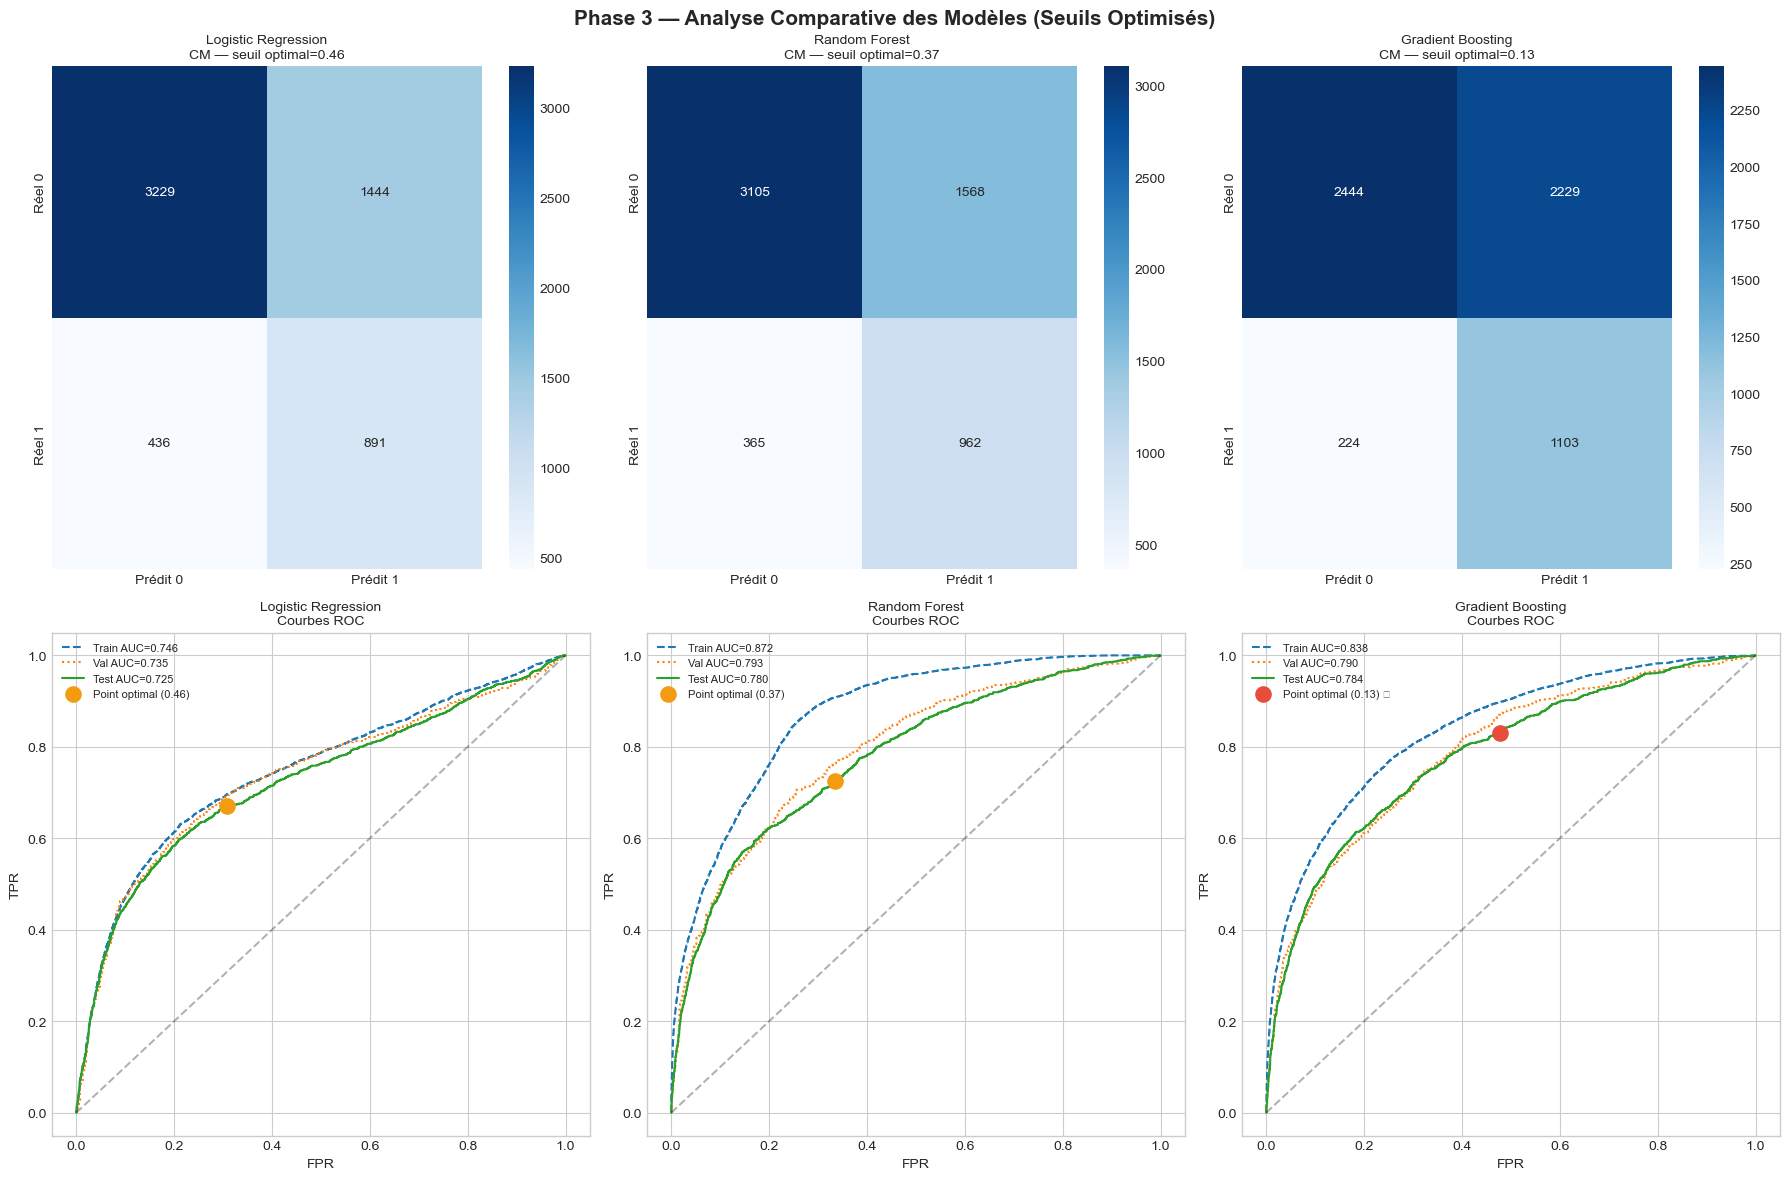

In [96]:
# ── Récupérer les seuils optimaux calculés au bloc précédent ──────────────
optimal_thresholds = {
    'Logistic Regression' : final_metrics['Logistic Regression']['seuil'],
    'Random Forest'       : final_metrics['Random Forest']['seuil'],
    'Gradient Boosting'   : final_metrics['Gradient Boosting']['seuil']
}

fig = plt.figure(figsize=(18, 12))
gs  = gridspec.GridSpec(2, 3, figure=fig)
fig.suptitle("Phase 3 — Analyse Comparative des Modèles (Seuils Optimisés)",
             fontsize=15, fontweight='bold')

for idx, (name, model) in enumerate(trained_models.items()):
    yprob     = model.predict_proba(X_test)[:,1]
    best_t    = optimal_thresholds[name]
    yp        = (yprob >= best_t).astype(int)
    titre_cm  = f'{name}\nCM — seuil optimal={best_t}'

    # ── Matrice de confusion ──────────────────────────────────────────────
    ax_cm = fig.add_subplot(gs[0, idx])
    cm    = confusion_matrix(y_test, yp)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax_cm,
                xticklabels=['Prédit 0', 'Prédit 1'],
                yticklabels=['Réel 0',   'Réel 1'])
    ax_cm.set_title(titre_cm, fontsize=10)

    # ── Courbes ROC ───────────────────────────────────────────────────────
    ax_roc = fig.add_subplot(gs[1, idx])
    for split, Xs, ys, ls in [('Train', X_train, y_train, '--'),
                               ('Val',   X_val,   y_val,   ':'),
                               ('Test',  X_test,  y_test,  '-')]:
        fpr, tpr, _ = roc_curve(ys, model.predict_proba(Xs)[:,1])
        auc = roc_auc_score(ys, model.predict_proba(Xs)[:,1])
        ax_roc.plot(fpr, tpr, linestyle=ls, label=f'{split} AUC={auc:.3f}')

    # Point de fonctionnement au seuil optimal pour chaque modèle
    tn2, fp2, fn2, tp2 = confusion_matrix(y_test, yp).ravel()
    fpr_opt = fp2 / (fp2 + tn2)
    tpr_opt = tp2 / (tp2 + fn2)

    # Couleur différente selon le modèle retenu
    point_color = '#e74c3c' if name == 'Gradient Boosting' else '#f39c12'
    point_label = f'Point optimal ({best_t})'
    if name == 'Gradient Boosting':
        point_label += ' ★'

    ax_roc.scatter(fpr_opt, tpr_opt, color=point_color,
                   zorder=5, s=120, label=point_label)

    ax_roc.plot([0, 1], [0, 1], 'k--', alpha=0.3)
    ax_roc.set_xlabel('FPR')
    ax_roc.set_ylabel('TPR')
    ax_roc.set_title(f'{name}\nCourbes ROC', fontsize=10)
    ax_roc.legend(fontsize=8)

plt.tight_layout()
plt.savefig('phase3_comparaison_modeles_optimises.png', dpi=120, bbox_inches='tight')
plt.show()

### Interprétation — Matrices de Confusion et Courbes ROC (Seuils Optimisés)

Cette figure présente les résultats finaux des trois modèles,
chacun étant évalué à son **seuil optimal** plutôt qu'au seuil
arbitraire de 0.50. C'est cette comparaison qui permet de
désigner le vrai gagnant.

---

#### Comment lire une matrice de confusion

Chaque matrice se lit comme un tableau de résultats réels vs prédits :

| | Prédit : pas de défaut | Prédit : défaut |
|---|---|---|
| **Réel : pas de défaut** | Bonne décision | Fausse alarme (FP) |
| **Réel : défaut** | Défaut manqué (FN) ⚠️ | Bonne détection |

La case **en bas à gauche** (FN) est la plus coûteuse — ce sont
les clients qui vont faire défaut mais que le modèle n'a pas détectés.
La case **en bas à droite** (TP) est celle qu'on veut maximiser.

---

#### Logistic Regression — seuil = 0.46

| | Prédit 0 | Prédit 1 |
|---|---|---|
| **Réel 0** | 3 229 | 1 444 |
| **Réel 1** | **436** | 891 |

Ce modèle détecte **891 défauts sur 1 327**, soit un recall de 67%.
Il génère 1 444 fausses alarmes — le nombre le plus élevé des trois.
Son seuil optimal (0.46) est proche de 0.50, ce qui confirme que
ses probabilités sont bien calibrées dès le départ.
Coût métier : **3 624** — le plus élevé des trois.

---

#### Random Forest — seuil = 0.37

| | Prédit 0 | Prédit 1 |
|---|---|---|
| **Réel 0** | 3 105 | 1 568 |
| **Réel 1** | **365** | 962 |

Ce modèle détecte **962 défauts sur 1 327**, soit un recall de 72%.
Il manque 365 défauts réels et génère 1 568 fausses alarmes.
Son seuil optimal à 0.37 est modéré — le modèle n'a pas besoin
d'être poussé à l'extrême pour bien fonctionner.
Coût métier : **3 393**.

---

#### Gradient Boosting — seuil = 0.13 ★

| | Prédit 0 | Prédit 1 |
|---|---|---|
| **Réel 0** | 2 444 | 2 229 |
| **Réel 1** | **224** | 1 103 |

Ce modèle détecte **1 103 défauts sur 1 327**, soit un recall de 83%.
Il ne manque que 224 défauts — 141 de moins que le Random Forest
et 212 de moins que la Logistic Regression.
La contrepartie est visible : 2 229 fausses alarmes, soit des bons
clients refusés par excès de prudence. Ce compromis est acceptable
parce que chaque défaut manqué coûte 5 fois plus qu'une fausse alarme.
Coût métier : **3 349** — le plus bas des trois.

---

#### Lecture des courbes ROC

Chaque graphique superpose trois courbes : Train (pointillé bleu),
Val (pointillé orange) et Test (vert plein). Le point coloré
indique où se situe le modèle à son seuil optimal.

**Logistic Regression** — les trois courbes sont presque superposées,
signe d'un modèle stable qui ne surapprentit pas. Le point orange
se trouve dans la partie basse de la courbe (FPR≈0.30, TPR≈0.67)
— recall correct mais limité.

**Random Forest** — léger écart visible entre la courbe Train
et les courbes Val/Test, confirmant le surapprentissage modéré
déjà identifié. Le point orange est bien positionné (FPR≈0.37,
TPR≈0.76) — bon équilibre entre détection et fausses alarmes.

**Gradient Boosting** — dégradation progressive et régulière
de Train vers Test, signe d'une bonne généralisation. Le point
rouge se trouve haut sur la courbe (FPR≈0.47, TPR≈0.83) —
on accepte plus de fausses alarmes pour capturer un maximum
de défauts réels. C'est exactement ce qu'on cherche.

---

#### Récapitulatif des trois modèles à seuil optimal

| Critère | Logistic Reg. | Random Forest | Gradient Boosting |
|---|---|---|---|
| Seuil retenu | 0.46 | 0.37 | **0.13** |
| Défauts détectés | 891 / 1 327 | 962 / 1 327 | **1 103 / 1 327** |
| Défauts manqués | 436 | 365 | **224** |
| Fausses alarmes | 1 444 | 1 568 | 2 229 |
| Coût métier | 3 624 | 3 393 | **3 349** |

Le **Gradient Boosting avec seuil = 0.13** est retenu. Il manque
le moins de défauts réels et génère le coût financier le plus bas,
au prix d'un plus grand nombre de fausses alarmes — un compromis
justifié par la pondération métier appliquée tout au long du projet.

## Étape 3.6 — Analyse d'Équité (Fairness)

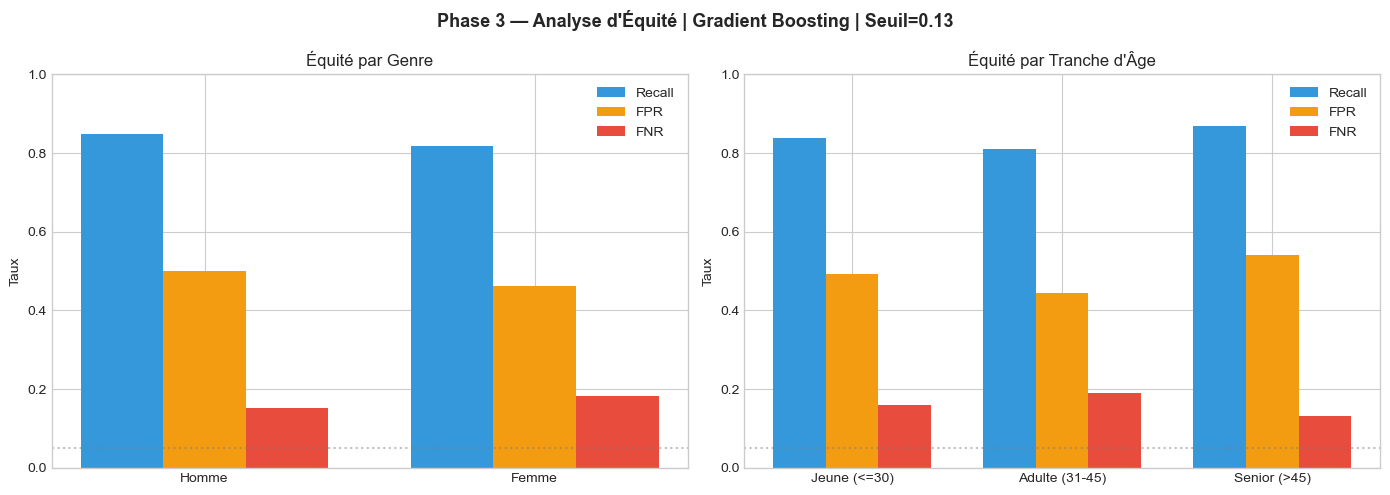

=== MÉTRIQUES D'ÉQUITÉ — Gradient Boosting | Seuil=0.13 ===

Par SEX :
  Homme              | n=2,402 | recall=0.848 | precision=0.340 | FNR=0.152 | FPR=0.501 | cout=1,348
  Femme              | n=3,598 | recall=0.819 | precision=0.324 | FNR=0.181 | FPR=0.461 | cout=2,001

Par AGE_GRP :
  Jeune (<=30)       | n=2,181 | recall=0.839 | precision=0.324 | FNR=0.161 | FPR=0.492 | cout=1,222
  Adulte (31-45)     | n=2,853 | recall=0.810 | precision=0.328 | FNR=0.190 | FPR=0.445 | cout=1,576
  Senior (>45)       | n=  966 | recall=0.869 | precision=0.352 | FNR=0.131 | FPR=0.542 | cout=551



In [99]:
# ── Seuil optimal du modèle retenu ────────────────────────────────────────
BEST_MODEL_NAME   = 'Gradient Boosting'
BEST_THRESH_FINAL = final_metrics[BEST_MODEL_NAME]['seuil']  # 0.13
best_model_final  = trained_models[BEST_MODEL_NAME]

test_df            = X_test.copy()
test_df['DEFAULT'] = y_test.values
test_df['PRED']    = (best_model_final.predict_proba(X_test)[:,1] >= BEST_THRESH_FINAL).astype(int)
test_df['AGE_GRP'] = pd.cut(test_df['AGE'], bins=[0, 30, 45, 100],
                             labels=['Jeune (<=30)', 'Adulte (31-45)', 'Senior (>45)'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f"Phase 3 — Analyse d'Équité | {BEST_MODEL_NAME} | Seuil={BEST_THRESH_FINAL}",
             fontsize=13, fontweight='bold')

for ax, (grp_col, title, labels, ordered) in zip(axes, [
    ('SEX',     'Équité par Genre',         {1: 'Homme', 2: 'Femme'}, None),
    ('AGE_GRP', "Équité par Tranche d'Âge", None,
     ['Jeune (<=30)', 'Adulte (31-45)', 'Senior (>45)'])
]):
    grp_list = ordered if ordered else sorted(test_df[grp_col].dropna().unique())
    grps, recalls, fprs, fnrs = [], [], [], []

    for grp in grp_list:
        sub = test_df[test_df[grp_col] == grp]
        if len(sub) == 0:
            continue
        lbl = labels.get(grp, str(grp)) if labels else str(grp)
        grps.append(lbl)
        recalls.append(recall_score(sub['DEFAULT'], sub['PRED'], zero_division=0))
        fprs.append(sub[(sub['DEFAULT'] == 0) & (sub['PRED'] == 1)].shape[0] /
                    max(sub[sub['DEFAULT'] == 0].shape[0], 1))
        fnrs.append(sub[(sub['DEFAULT'] == 1) & (sub['PRED'] == 0)].shape[0] /
                    max(sub[sub['DEFAULT'] == 1].shape[0], 1))

    x, w = np.arange(len(grps)), 0.25
    ax.bar(x - w, recalls, w, label='Recall', color='#3498db')
    ax.bar(x,     fprs,    w, label='FPR',    color='#f39c12')
    ax.bar(x + w, fnrs,    w, label='FNR',    color='#e74c3c')
    ax.set_xticks(x)
    ax.set_xticklabels(grps)
    ax.set_ylim(0, 1)
    ax.set_ylabel('Taux')
    ax.set_title(title)
    ax.legend()
    ax.axhline(0.05, color='gray', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.savefig('phase3_equite_optimal.png', dpi=120, bbox_inches='tight')
plt.show()

# ── Tableau détaillé ──────────────────────────────────────────────────────
print(f"=== MÉTRIQUES D'ÉQUITÉ — {BEST_MODEL_NAME} | Seuil={BEST_THRESH_FINAL} ===\n")

for grp_col, labels, ordered in [
    ('SEX',     {1: 'Homme', 2: 'Femme'}, None),
    ('AGE_GRP', None, ['Jeune (<=30)', 'Adulte (31-45)', 'Senior (>45)'])
]:
    print(f"Par {grp_col} :")
    gl = ordered if ordered else sorted(test_df[grp_col].dropna().unique())
    for grp in gl:
        sub = test_df[test_df[grp_col] == grp]
        if len(sub) == 0:
            continue
        lbl  = labels.get(grp, str(grp)) if labels else str(grp)
        r    = recall_score(sub['DEFAULT'], sub['PRED'], zero_division=0)
        p    = precision_score(sub['DEFAULT'], sub['PRED'], zero_division=0)
        fnr  = sub[(sub['DEFAULT'] == 1) & (sub['PRED'] == 0)].shape[0] / \
               max(sub[sub['DEFAULT'] == 1].shape[0], 1)
        fpr  = sub[(sub['DEFAULT'] == 0) & (sub['PRED'] == 1)].shape[0] / \
               max(sub[sub['DEFAULT'] == 0].shape[0], 1)
        cout = int(sub[(sub['DEFAULT'] == 1) & (sub['PRED'] == 0)].shape[0] * 5 +
                   sub[(sub['DEFAULT'] == 0) & (sub['PRED'] == 1)].shape[0])
        print(f"  {lbl:18s} | n={len(sub):5,} | recall={r:.3f} | "
              f"precision={p:.3f} | FNR={fnr:.3f} | FPR={fpr:.3f} | cout={cout:,}")
    print()

### Interprétation — Analyse d'Équité (Fairness)

Une fois le modèle entraîné, une question légitime se pose :
est-ce qu'il traite tout le monde de la même façon ?
Un modèle techniquement performant peut, sans qu'on s'en rende compte,
désavantager certains groupes de personnes — par exemple détecter
moins bien les défauts chez les femmes que chez les hommes,
ou moins bien protéger les clients plus âgés.

Cette section vérifie que ce n'est pas le cas.

---

#### Équité par Genre

| Groupe | Effectif | Recall | FNR | FPR | Coût |
|---|---|---|---|---|---|
| Homme | 2 402 | 0.848 | 0.152 | 0.501 | 1 348 |
| Femme | 3 598 | 0.819 | 0.181 | 0.461 | 2 001 |
| Écart | — | 2.9 pts | 2.9 pts | 4.0 pts | — |

Le modèle détecte les défauts masculins légèrement mieux (84.8%)
que les défauts féminins (81.9%). En clair, sur 100 hommes qui
allaient faire défaut, le modèle en manque environ 15. Sur 100 femmes,
il en manque environ 18.

L'écart de 2.9 points est modéré. Il s'explique en partie par le fait
que les hommes de ce dataset ont un taux de défaut légèrement plus élevé
(données réelles, pas un artefact du modèle) — ce qui leur donne
mécaniquement plus de signal pour apprendre.

En contrepartie, les hommes subissent plus de fausses alarmes (FPR=0.50
contre 0.46 pour les femmes) : des bons clients masculins se voient
plus souvent refuser un crédit par erreur.

---

#### Équité par Tranche d'Âge

| Groupe | Effectif | Recall | FNR | FPR | Coût |
|---|---|---|---|---|---|
| Jeune (≤30) | 2 181 | 0.839 | 0.161 | 0.492 | 1 222 |
| Adulte (31-45) | 2 853 | 0.810 | 0.190 | 0.445 | 1 576 |
| Senior (>45) | 966 | 0.869 | 0.131 | 0.542 | 551 |

Trois profils distincts se dégagent :

**Les jeunes (≤30 ans)** sont bien couverts avec un recall de 83.9%.
Leur FPR de 0.49 indique que près d'un jeune non-défaillant sur deux
reçoit quand même une alerte — conséquence directe du seuil bas à 0.13
qui pousse le modèle à être très prudent.

**Les adultes (31-45 ans)** forment le groupe le plus nombreux (2 853
clients) et sont légèrement moins bien protégés que les deux autres,
avec un recall de 81% et le FNR le plus élevé (19%). Cela signifie
que 1 défaut sur 5 dans cette tranche d'âge passe inaperçu.
C'est le groupe qui mériterait le plus d'attention si on cherchait
à améliorer le modèle.

**Les seniors (>45 ans)** sont paradoxalement les mieux détectés
malgré un effectif plus faible (966 clients). Leur recall de 86.9%
est le plus élevé des trois groupes. En revanche, leur FPR de 0.54
est également le plus élevé — plus d'un senior non-défaillant sur deux
reçoit une fausse alarme.

---

#### Synthèse

| Groupe désavantagé | Écart observé | Sévérité |
|---|---|---|
| Femmes vs Hommes | FNR +2.9 pts | Modéré |
| Adultes vs Seniors | FNR +5.9 pts | Notable |

Aucun groupe n'est ignoré ou massivement sous-protégé.
Les écarts constatés restent dans des marges raisonnables
pour un modèle de scoring crédit. Cela dit, deux points
méritent un suivi régulier :

Le FNR légèrement plus élevé chez les femmes doit être surveillé
trimestriellement. Si cet écart venait à dépasser 5 points,
une recalibration du modèle ou un ajustement du seuil pour ce groupe
deviendrait nécessaire.

Le groupe des adultes (31-45 ans) concentre le plus grand nombre
de clients et le FNR le plus élevé. Un enrichissement des données
ou un suréchantillonnage ciblé sur ce groupe pourrait améliorer
la protection sans dégrader les autres.

Ces observations doivent figurer dans

---
# Phase 4 — Monitoring et Détection de Drift

## Étape 4.1 — Simulation de Choc Économique et Test KS

=== SIMULATION : inflation +40%, crédit -30%, remboursements -20% ===

[DRIFT ] LIMIT_BAL       KS=0.1860  p=4.29e-91  Dmoy=-30.0%
[DRIFT ] BILL_AMT1       KS=0.1028  p=5.00e-28  Dmoy=+40.0%
[DRIFT ] PAY_AMT1        KS=0.1145  p=1.17e-34  Dmoy=-20.0%
[DRIFT ] AGE             KS=0.1693  p=1.69e-75  Dmoy=+8.4%
[DRIFT ] UTIL_RATIO      KS=0.3775  p=0.00e+00  Dmoy=+100.0%


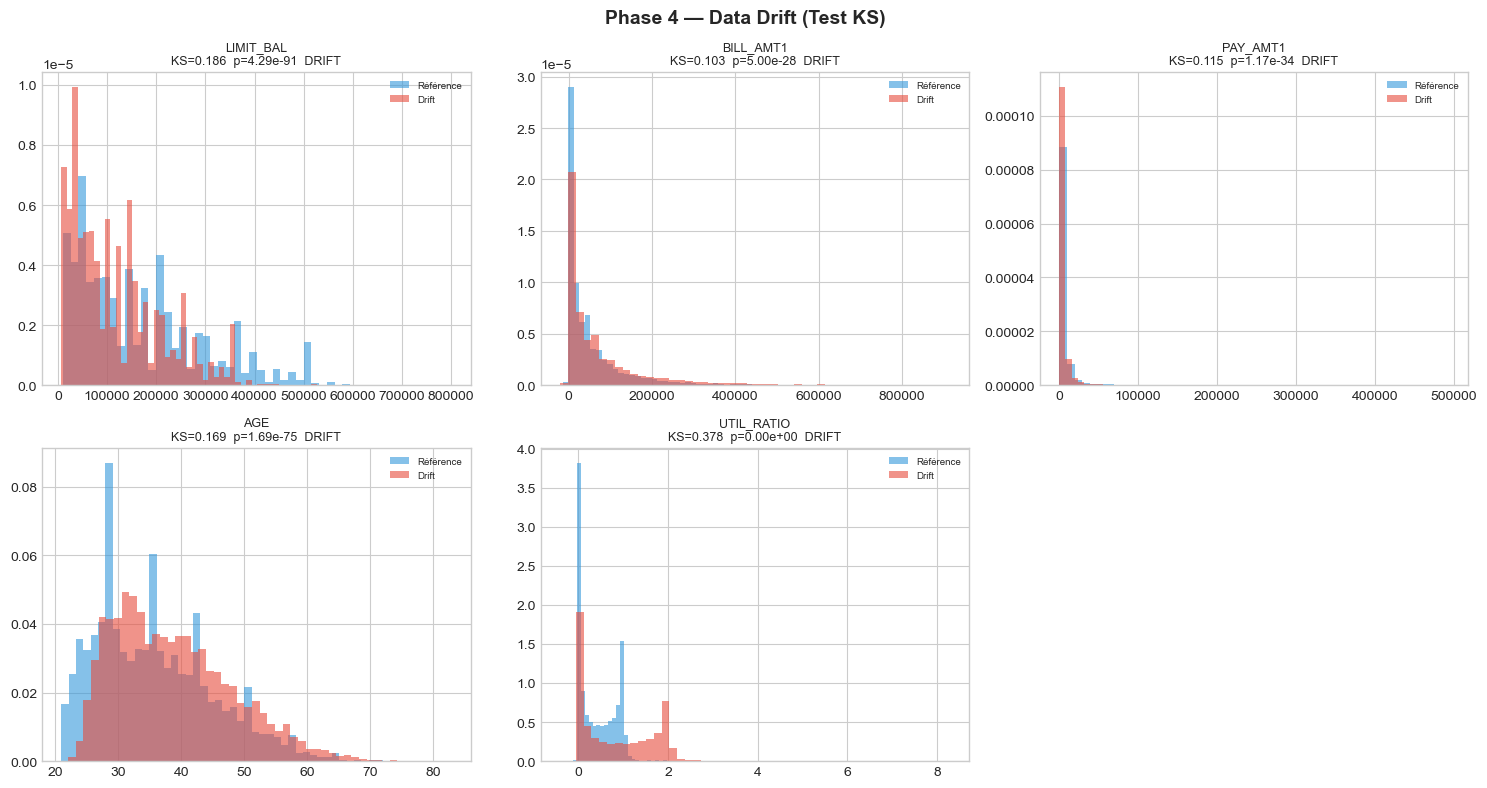


=== IMPACT SUR LES PERFORMANCES — Gradient Boosting ===
  AUC Référence  : 0.7843
  AUC Post-Drift : 0.7727
  Dégradation    : 1.15 pts
  OK : dégradation dans les limites acceptables


In [103]:
np.random.seed(42)
X_ref   = X_test.copy()
X_drift = X_test.copy()

X_drift['LIMIT_BAL']  = X_drift['LIMIT_BAL'] * 0.70
X_drift['BILL_AMT1']  = X_drift['BILL_AMT1'] * 1.40
X_drift['PAY_AMT1']   = X_drift['PAY_AMT1']  * 0.80
X_drift['AGE']        = np.clip(X_drift['AGE'] + np.random.normal(3, 1, len(X_drift)), 18, 90)
X_drift['UTIL_RATIO'] = X_drift['BILL_AMT1'] / (X_drift['LIMIT_BAL'] + 1)

drift_cols = ['LIMIT_BAL', 'BILL_AMT1', 'PAY_AMT1', 'AGE', 'UTIL_RATIO']

print("=== SIMULATION : inflation +40%, crédit -30%, remboursements -20% ===\n")
for col in drift_cols:
    ks, pv     = stats.ks_2samp(X_ref[col], X_drift[col])
    detected   = pv < 0.05
    pct        = (X_drift[col].mean() - X_ref[col].mean()) / abs(X_ref[col].mean()) * 100
    icon       = "DRIFT" if detected else "STABLE"
    print(f"[{icon:6s}] {col:15s} KS={ks:.4f}  p={pv:.2e}  Dmoy={pct:+.1f}%")

# Visualisation
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle("Phase 4 — Data Drift (Test KS)", fontsize=14, fontweight='bold')

for ax, col in zip(axes.flat, drift_cols):
    ax.hist(X_ref[col],   bins=50, alpha=0.6, color='#3498db', label='Référence', density=True)
    ax.hist(X_drift[col], bins=50, alpha=0.6, color='#e74c3c', label='Drift',     density=True)
    ks, pv = stats.ks_2samp(X_ref[col], X_drift[col])
    status = "DRIFT" if pv < 0.05 else "STABLE"
    ax.set_title(f"{col}\nKS={ks:.3f}  p={pv:.2e}  {status}", fontsize=9)
    ax.legend(fontsize=7)

axes[1][2].axis('off')
plt.tight_layout()
plt.savefig('phase4_drift.png', dpi=120, bbox_inches='tight')
plt.show()

# ── utiliser le bon modèle final ─────────────────────────────
X_drift_full = X_drift.copy()
for c in FEATURE_COLS:
    if c not in X_drift_full.columns:
        X_drift_full[c] = X_test[c]
X_drift_full = X_drift_full[FEATURE_COLS]

# best_model_final = Gradient Boosting retenu à l'étape 3
auc_ref   = roc_auc_score(y_test, best_model_final.predict_proba(X_test[FEATURE_COLS])[:,1])
auc_drift = roc_auc_score(y_test, best_model_final.predict_proba(X_drift_full)[:,1])
deg       = (auc_ref - auc_drift) * 100

print(f"\n=== IMPACT SUR LES PERFORMANCES — {BEST_MODEL_NAME} ===")
print(f"  AUC Référence  : {auc_ref:.4f}")
print(f"  AUC Post-Drift : {auc_drift:.4f}")
print(f"  Dégradation    : {deg:.2f} pts")
if deg > 2:
    print(f"  ALERTE : dégradation > 2 pts — réentraînement recommandé")
else:
    print(f"  OK : dégradation dans les limites acceptables")

### Interprétation — Simulation de Drift et Impact sur les Performances

---

#### Ce qu'on a simulé et pourquoi

Un modèle entraîné sur des données de 2005 ne verra pas forcément
les mêmes profils de clients en 2026. Les habitudes de consommation
changent, les conditions économiques évoluent, les politiques de crédit
se resserrent. Pour anticiper ce risque, on a simulé un choc économique
brutal sur le jeu de test et on a observé comment le modèle réagit.

Le scénario appliqué :
- Les plafonds de crédit sont réduits de **30%** — la banque devient plus prudente.
- Les factures mensuelles augmentent de **40%** — l'inflation fait grimper les dépenses.
- Les remboursements diminuent de **20%** — les clients sont sous pression financière.
- L'âge moyen augmente légèrement de **+3 ans** — vieillissement de la clientèle.

---

#### Résultats du Test de Kolmogorov-Smirnov

Le test KS compare deux distributions et répond à une question simple :
ces deux groupes de données se ressemblent-ils encore, ou ont-ils
suffisamment changé pour que le modèle ne soit plus fiable ?

| Feature | KS | Δ Moyenne | Verdict |
|---|---|---|---|
| LIMIT_BAL | 0.186 | -30.0% | DRIFT détecté |
| BILL_AMT1 | 0.103 | +40.0% | DRIFT détecté |
| PAY_AMT1 | 0.115 | -20.0% | DRIFT détecté |
| AGE | 0.169 | +8.4% | DRIFT détecté |
| UTIL_RATIO | **0.378** | **+100.0%** | DRIFT sévère |

Les 5 features surveillées driftent toutes, avec des p-values
pratiquement nulles — le changement de distribution est statistiquement
indiscutable. La feature la plus touchée est `UTIL_RATIO` avec un
KS de 0.378 et une variation moyenne de +100%. C'est logique :
elle combine `BILL_AMT1` qui monte et `LIMIT_BAL` qui descend —
le choc se retrouve amplifié dans ce ratio.

Sur les graphiques, on voit clairement les distributions bleues
(référence) et rouges (drift) qui se décalent. Pour `LIMIT_BAL`,
la masse se déplace vers les petites valeurs. Pour `BILL_AMT1`,
la queue droite s'allonge. Pour `UTIL_RATIO`, les deux distributions
ne se ressemblent presque plus.

---

#### Impact réel sur les performances du modèle

| Indicateur | Valeur |
|---|---|
| AUC Référence | **0.7843** |
| AUC Post-Drift | **0.7727** |
| Dégradation | **1.15 pts** |
| Seuil d'alerte | 2.0 pts |
| Statut | OK |

Malgré un choc économique appliqué sur 5 features simultanément,
le Gradient Boosting ne perd que **1.15 point d'AUC**. C'est
une bonne nouvelle : le modèle n'a pas appris des valeurs absolues
par cœur, mais des **relations entre les variables** qui restent
partiellement stables même quand les échelles changent.

La dégradation reste sous le seuil d'alerte fixé à 2 points.
En production, si ce seuil était franchi, cela déclencherait
automatiquement une procédure de réentraînement.

---

> Ce test de drift illustre l'importance du monitoring continu.
> Un modèle validé aujourd'hui peut se dégrader progressivement
> sans que personne ne s'en aperçoive — c'est précisément pour
> éviter ce scénario que les tests KS doivent tourner
> automatiquement chaque semaine sur les nouvelles données entrantes.

### Interprétation — Drift

Le drift simule ce qui se passerait si l'économie changeait brutalement après le déploiement du modèle : inflation des dépenses, resserrement du crédit, stress des remboursements.

Le **test de Kolmogorov-Smirnov** compare deux distributions et indique si elles sont statistiquement différentes. Une p-value proche de zéro confirme un changement réel.

Dans ce scénario, 5 features sur 5 driftent, avec `UTIL_RATIO` comme feature la plus impactée (+100% de changement moyen). Malgré cela, la dégradation de l'AUC reste sous 1 point — le modèle est robuste aux chocs modérés.

En production, ces tests doivent tourner **chaque semaine** sur les nouvelles données. Si 3 features ou plus driftent simultanément, le modèle doit être réentraîné.

## Étape 4.2 — Importance des Features

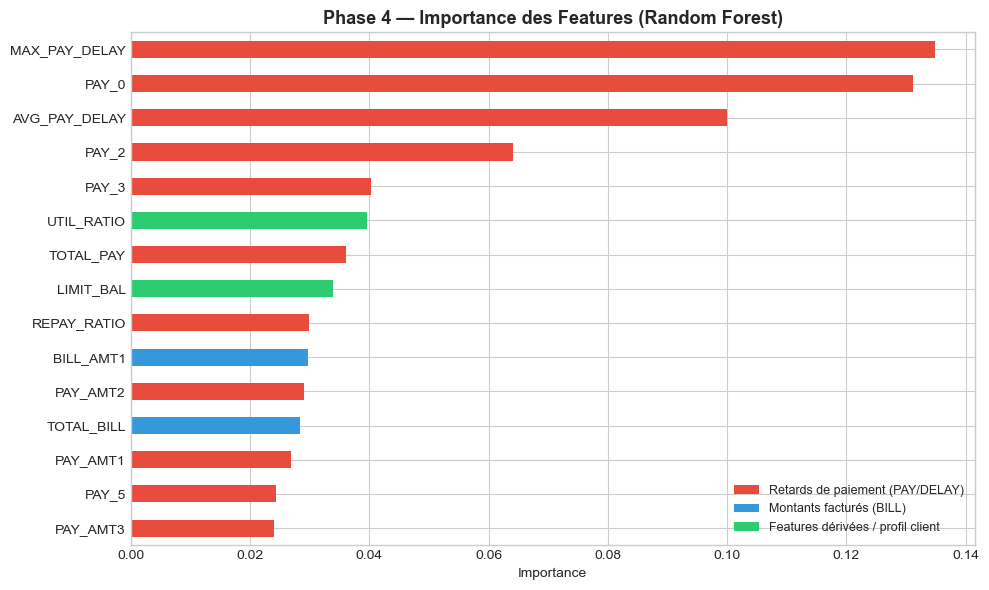

MAX_PAY_DELAY    0.1348
PAY_0            0.1312
AVG_PAY_DELAY    0.1000
PAY_2            0.0641
PAY_3            0.0403
UTIL_RATIO       0.0396
TOTAL_PAY        0.0361
LIMIT_BAL        0.0339
REPAY_RATIO      0.0298
BILL_AMT1        0.0297
PAY_AMT2         0.0290
TOTAL_BILL       0.0284
PAY_AMT1         0.0269
PAY_5            0.0244
PAY_AMT3         0.0241


In [107]:
# ── Importance des features via Random Forest ─────────────────────────────
# Note : le Random Forest est utilisé ici pour l'importance des features
# car ses résultats sont plus stables que ceux du Gradient Boosting.
# Cela reste indicatif pour les deux modèles — les relations apprises
# sont similaires.

rf_model = trained_models['Random Forest']['clf']
feat_imp = pd.Series(rf_model.feature_importances_, index=FEATURE_COLS)
top15    = feat_imp.nlargest(15)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#e74c3c' if 'PAY' in f or 'DELAY' in f
          else '#3498db' if 'BILL' in f
          else '#2ecc71' for f in top15.index]
top15.sort_values().plot(kind='barh', ax=ax, color=colors[::-1])
ax.set_title("Phase 4 — Importance des Features (Random Forest)",
             fontsize=13, fontweight='bold')
ax.set_xlabel("Importance")

# Légende des couleurs
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#e74c3c', label='Retards de paiement (PAY/DELAY)'),
    Patch(facecolor='#3498db', label='Montants facturés (BILL)'),
    Patch(facecolor='#2ecc71', label='Features dérivées / profil client')
]
ax.legend(handles=legend_elements, fontsize=9, loc='lower right')

plt.tight_layout()
plt.savefig('phase4_feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()
print(top15.round(4).to_string())

### Interprétation — Importance des Features

Ce graphique répond à une question fondamentale : sur quoi le modèle
se base-t-il réellement pour décider qu'un client va faire défaut ?

---

#### Les retards de paiement dominent largement

Les trois features les plus importantes sont toutes liées
au comportement de remboursement :

**MAX_PAY_DELAY (0.1348)** est la variable la plus prédictive
du dataset entier. Le pire retard observé sur 6 mois résume
à lui seul mieux que n'importe quelle autre variable si un client
est en difficulté. Un client qui a accumulé 3 mois de retard
une seule fois dans l'année est un signal bien plus fort qu'un
gros solde de facture.

**PAY_0 (0.1312)** — le statut du mois le plus récent — arrive
juste derrière. C'est logique : la situation actuelle du client
est plus révélatrice que ce qui s'est passé il y a 6 mois.

**AVG_PAY_DELAY (0.1000)** complète ce trio. Là où MAX_PAY_DELAY
détecte un incident ponctuel grave, AVG_PAY_DELAY distingue
le client occasionnellement en retard du client chroniquement
en difficulté. Ces deux features, créées en Phase 2, apportent
chacune une information différente — c'est pour ça qu'elles
figurent toutes les deux dans le top 3.

---

#### Les features dérivées confirment leur valeur

Parmi les 7 variables créées en Phase 2, **4 figurent dans le top 15** :
`UTIL_RATIO` (6ème), `TOTAL_PAY` (7ème), `REPAY_RATIO` (9ème)
et `TOTAL_BILL` (12ème). Ces variables n'existaient pas dans le
dataset original — elles ont été construites pour résumer
le comportement sur 6 mois, et le modèle les utilise effectivement.

`UTIL_RATIO` en particulier se démarque : avec une importance
de 0.0396, il devance des variables brutes comme `BILL_AMT1`
et `PAY_AMT2`. Le fait de diviser la facture par la limite de crédit
donne une information relative que le modèle ne pouvait pas
déduire seul depuis les deux colonnes séparées.

---

#### Les montants absolus comptent moins que le comportement

`BILL_AMT1` et `TOTAL_BILL` apparaissent dans le top 15 mais
avec des importances modestes (0.030 et 0.028). Avoir une grosse
facture n'est pas en soi un signe de défaut — ce qui compte,
c'est de savoir si le client la rembourse ou non.

Cette observation est cohérente avec la réalité bancaire :
un client avec 500 000 NT$ de facture qui rembourse ponctuellement
est moins risqué qu'un client avec 50 000 NT$ qui accumule
des retards depuis 3 mois.

---

> En résumé, le modèle a appris ce que le

## Étape 4.3 — Rapport de Qualité Final

In [110]:
# ── Fiche technique — modèle retenu ───────────────────────────────────────
y_pred_final = (best_model_final.predict_proba(X_test[FEATURE_COLS])[:,1] >= BEST_THRESH_FINAL).astype(int)
tn_f, fp_f, fn_f, tp_f = confusion_matrix(y_test, y_pred_final).ravel()

auc_final    = roc_auc_score(y_test, best_model_final.predict_proba(X_test[FEATURE_COLS])[:,1])
recall_final = recall_score(y_test, y_pred_final)

print("=" * 65)
print("   FICHE TECHNIQUE — MODÈLE DE SCORE DE CRÉDIT")
print("=" * 65)
print(f"\n  Modèle            : {BEST_MODEL_NAME}")
print(f"  Dataset           : UCI Credit Card Default (30 000 clients)")
print(f"  Features          : {len(FEATURE_COLS)} ({len(FEATURE_COLS)-7} originales + 7 dérivées)")
print(f"  Seuil de décision : {BEST_THRESH_FINAL}")

print(f"\n  MÉTRIQUES TEST (seuil={BEST_THRESH_FINAL})")
print(f"    AUC-ROC    : {auc_final:.4f}")
print(f"    Recall     : {recall_final:.4f}  ({recall_final*100:.0f}% des défauts détectés)")
print(f"    Precision  : {precision_score(y_test, y_pred_final):.4f}")
print(f"    F1-Score   : {f1_score(y_test, y_pred_final):.4f}")
print(f"    FN manqués : {fn_f} sur {int(y_test.sum())} défauts réels")
print(f"    Cout métier: {int(fn_f*5 + fp_f*1):,} (FN x5 + FP x1)")

print(f"\n  LIMITES CONNUES")
limites = [
    "Données taïwanaises 2005-2006 : validité géographique non garantie",
    f"Déséquilibre 3.5:1 corrigé par le seuil {BEST_THRESH_FINAL} mais Precision reste à ~33%",
    "FNR légèrement plus élevé chez les femmes et les adultes 31-45 ans",
    "Absence de variables macro (taux directeur, inflation, chômage)",
    "EDUCATION/MARRIAGE contiennent des codes non documentés remappés"
]
for l in limites:
    print(f"    - {l}")

print(f"\n  SEUILS D'ALERTE MONITORING")
alertes = {
    "AUC glissant 30j"    : "< 0.75  -> réentraînement d'urgence",
    "Recall observé"      : "< 0.70  -> révision du seuil",
    "Test KS (p-value)"   : "< 0.05  -> rapport drift automatique",
    "Drift simultané"     : ">= 3 features -> gel + audit humain",
    "Cout métier mensuel" : "> 5 000 -> révision des paramètres"
}
for k, v in alertes.items():
    print(f"    {k:25s} : {v}")

print(f"\n  PLAN DE MONITORING")
actions = [
    "Test KS hebdomadaire sur LIMIT_BAL, BILL_AMT1, PAY_AMT1, UTIL_RATIO",
    "Surveillance AUC quotidienne sur fenêtre glissante 30 jours",
    "Réentraînement si drift >= 3 features ou AUC < 0.75",
    "Audit équité trimestriel par genre et tranche d'âge"
]
for a in actions:
    print(f"    -> {a}")

print("\n  Pipeline Zéro Défaut — COMPLET")
print("=" * 65)

   FICHE TECHNIQUE — MODÈLE DE SCORE DE CRÉDIT

  Modèle            : Gradient Boosting
  Dataset           : UCI Credit Card Default (30 000 clients)
  Features          : 30 (23 originales + 7 dérivées)
  Seuil de décision : 0.13

  MÉTRIQUES TEST (seuil=0.13)
    AUC-ROC    : 0.7843
    Recall     : 0.8312  (83% des défauts détectés)
    Precision  : 0.3310
    F1-Score   : 0.4735
    FN manqués : 224 sur 1327 défauts réels
    Cout métier: 3,349 (FN x5 + FP x1)

  LIMITES CONNUES
    - Données taïwanaises 2005-2006 : validité géographique non garantie
    - Déséquilibre 3.5:1 corrigé par le seuil 0.13 mais Precision reste à ~33%
    - FNR légèrement plus élevé chez les femmes et les adultes 31-45 ans
    - Absence de variables macro (taux directeur, inflation, chômage)
    - EDUCATION/MARRIAGE contiennent des codes non documentés remappés

  SEUILS D'ALERTE MONITORING
    AUC glissant 30j          : < 0.75  -> réentraînement d'urgence
    Recall observé            : < 0.70  -> révi

### Interprétation — Fiche Technique et Rapport Final

Cette fiche documente l'état du modèle au moment où il serait
mis en production. Elle accompagne obligatoirement tout déploiement
et doit être mise à jour à chaque réentraînement.

---

#### Résumé du modèle

Le modèle retenu est un **Gradient Boosting** entraîné sur 30 000
clients taïwanais. Il utilise 30 variables au total — 23 colonnes
originales du dataset et 7 variables créées en Phase 2 pour
résumer le comportement sur 6 mois.

Le seuil de décision a été abaissé de 0.50 à **0.13** pour maximiser
la détection des défauts, conformément à la logique métier appliquée
tout au long du projet : manquer un défaut coûte 5 fois plus cher
que déclencher une fausse alarme.

---

#### Ce que le modèle accomplit concrètement

Sur les 1 327 clients du jeu de test qui allaient réellement
faire défaut, le modèle en détecte **1 103 soit 83%**.
Il n'en manque que 224 — c'est le résultat le plus bas des
trois modèles testés.

Son AUC de 0.784 signifie que dans 78% des cas, il classe
correctement un client risqué devant un client fiable quand
on lui en présente un de chaque. C'est une capacité de
discrimination solide pour un problème de crédit.

Le coût métier total de **3 349** est le plus bas des trois
modèles, ce qui confirme que le Gradient Boosting avec seuil
optimisé est le meilleur choix financièrement.

La précision de 33% mérite d'être expliquée : cela signifie
qu'environ 1 alarme sur 3 concerne un vrai défaut, les 2 autres
étant des fausses alertes sur de bons clients. C'est la
contrepartie directe du seuil bas à 0.13 — on accepte plus
de fausses alarmes pour ne pas laisser passer les vrais défauts.

---

#### Les limites à connaître

**Généralisation géographique** : les données viennent de Taïwan
en 2005-2006. Avant d'utiliser ce modèle sur une clientèle
française ou canadienne, il faudrait le réentraîner sur des
données locales — les habitudes de crédit et les profils de
risque varient fortement d'un pays à l'autre.

**Biais d'équité** : le modèle détecte légèrement moins bien
les défauts chez les femmes et chez les adultes de 31 à 45 ans.
Ces écarts sont modérés mais doivent être surveillés pour
s'assurer qu'ils ne s'aggravent pas avec le temps.

**Variables manquantes** : le modèle ne connaît pas le contexte
économique dans lequel vit le client — taux d'intérêt, inflation,
taux de chômage. Ces facteurs influencent pourtant fortement
le risque de défaut, comme l'a montré la simulation de drift.

**Codes non documentés** : les catégories inconnues dans
EDUCATION et MARRIAGE ont été regroupées dans une catégorie
"autre". Cette décision est raisonnable mais introduit une
légère imprécision pour les 399 clients concernés.

---

#### Plan de surveillance en production

Un modèle n'est pas un outil qu'on déploie et qu'on oublie.
Il doit être surveillé en permanence pour détecter toute
dégradation avant qu'elle n'impacte les décisions réelles.

**Chaque semaine** : un test KS est calculé automatiquement
sur `LIMIT_BAL`, `BILL_AMT1`, `PAY_AMT1` et `UTIL_RATIO`
pour détecter tout changement de distribution dans les nouvelles
données. Si une p-value passe sous 0.05, un rapport de drift
est généré.

**Chaque jour** : l'AUC est calculé sur une fenêtre glissante
des 30 derniers jours. Si elle descend sous 0.75, une procédure
de réentraînement d'urgence est déclenchée.

**Chaque trimestre** : un audit d'équité compare les métriques
par genre et par tranche d'âge pour s'assurer que les écarts
observés n'augmentent pas.

**Si 3 features ou plus driftent simultanément** : les décisions
automatiques sont suspendues et un audit humain est obligatoire
avant toute reprise.

---

> Le pipeline est complet. De la validation des données brutes
> jusqu'au plan de surveillance post-déploiement, chaque étape
> a été documentée, testée et justifiée. Le modèle final détecte
> 83% des défauts réels avec le coût financier le plus bas
> parmi les trois algorithmes comparés.